# Lesson133 · Heterogeneous convolution on a relational entity graph

Student lab · Three live TODOs, unchanged CHECKs, synthetic optimization and author-evidence replay. Fresh full-data training is gated separately.

In [ ]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


In [ ]:
import copy,json,hashlib,importlib.metadata
from pathlib import Path
import torch
torch.set_num_threads(1)
from torch_geometric.nn import SAGEConv,HeteroConv

<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 132 to this lesson</p>
<p>Root identity tells us whose question is being answered. The next step is to reconstruct exactly what each incoming relation contributes to one row.</p>
<details><summary>Quick prerequisite reminder</summary><p>Sum within a relation combines neighbor vectors. Sum across relations combines complete relation outputs, including their root transforms and biases. Empty edges and an absent relation key differ.</p></details>
</aside>
<!-- sequence-review:end -->



## The next question: what exactly reaches a row?

[Lesson 131](https://avistian.github.io/relational/lessons/0131-gnn-tabular-stack.html) followed a prediction through the whole tabular–graph stack. [Lesson 132](https://avistian.github.io/relational/lessons/0132-identity-aware-message-passing.html) distinguished a node's table type from its identity relative to a query. Neither distinction tells you the numerical update inside one heterogeneous layer. That is today's tangible win: **reconstruct one destination row's update, then prove your code computes the released operator.**

A relational entity graph (REG) represents table rows as nodes and foreign-key links as typed edges. “Heterogeneous” means different node and relation types can have different parameters. It does not mean every row gets its own weights. This matters to our mission: a learned relational baseline must have an inspectable path from linked rows to a prediction.

Spend about 15 minutes on the trace and 30–45 minutes on the notebook. The full reproduction appendix is an author/reference track; executing it is not proof you can explain the layer.

**Retrieve first.** What does each row of `edge_index` index? Why is “row 7” ambiguous without its table? What makes a reverse relation different from a self-loop? Write answers before opening the explanations below.

<details><summary>Check the retrieval before continuing</summary><p>Edge row 0 indexes source rows; edge row 1 indexes destination rows. A local index needs its table and sampled graph to identify an occurrence. A reverse relation sends messages in the opposite direction across a stored relationship; a self-loop connects a node to itself.</p></details>



## 1 · Locate the layer in the complete model

A task row identifies a driver, a prediction time and a future position label. The sampler supplies a separate past context for each query. Table-specific row encoders turn mixed columns into width-128 vectors; relative-time vectors are added. Two heterogeneous GraphSAGE layers update these vectors. A scalar head reads the query driver vectors, and mean absolute error trains the system.

<figure class="stream-figure" tabindex="0">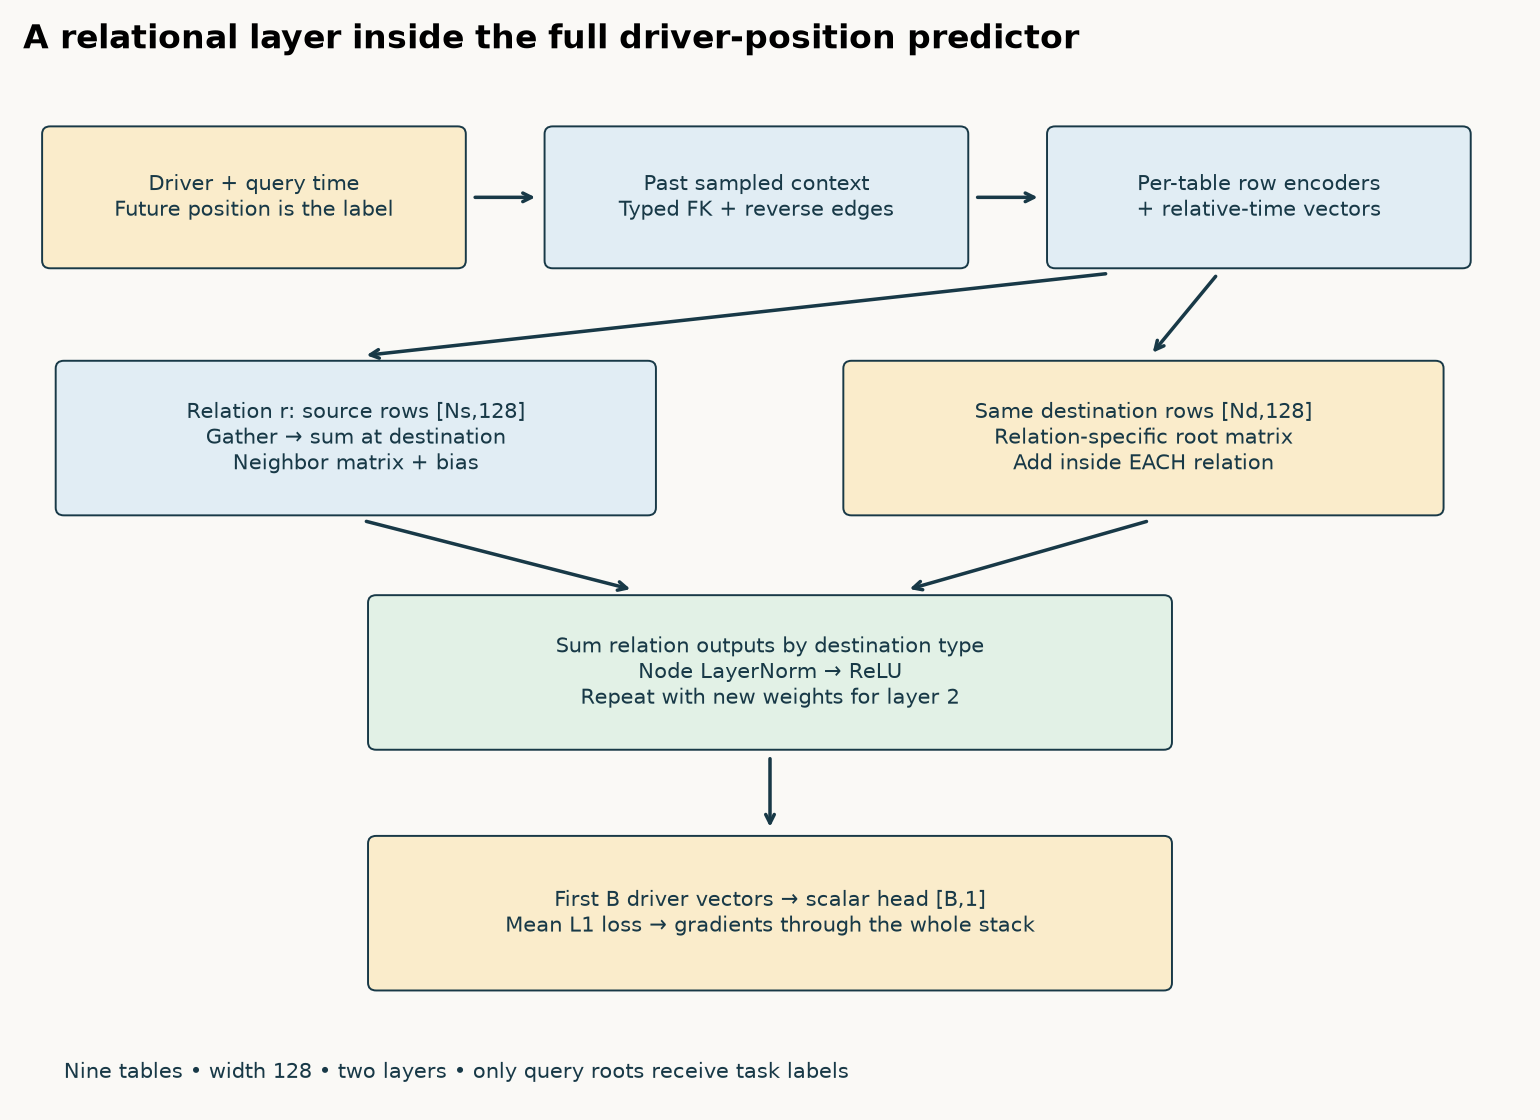<figcaption>The full driver-position predictor, with the two sums and per-relation root transforms opened inside the graph layer.</figcaption></figure>

**Diagram trace.** Find the two sums: neighbors within a relation, then complete outputs across relations. Count how often a root transform contributes. On a narrow screen, scroll the figure sideways.

The layer receives two dictionaries: `x_dict[type]` has shape `[N_type, 128]`; `edge_index_dict[(source, relation, destination)]` has shape `[2, E_relation]`. The first edge row indexes source features and the second indexes destination features. These are local occurrence indices inside the sampled graph, not arbitrary database primary keys. The loader already enforces query ownership and time eligibility; convolution cannot repair a future row admitted upstream.

The [released RelBench implementation](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/nn.py) creates one SAGEConv per directed relation and one normalization module per destination table. The selected experiment sets the inner aggregation to **sum**, overriding the wrapper's default **mean**. The outer HeteroConv also uses sum. Those are two separate choices.



## 2 · First sum: neighbors within one relation

Consider orders belonging to customers. Two order vectors, reduced to scalars 1 and 2 for this exercise, point to customer 0. Their neighbor sum is 3. Customer 1 has no incoming orders, so its neighbor sum is 0. Do not divide by degree: that would be a different operator.

**TODO 1 — `sum_neighbors`.** Gather source features using edge row 0, then add them into destination rows using edge row 1. Allocate all destination rows, including those with no neighbors. Preserve repeated edges: the operator consumes an edge multiset. The production graph builder may deduplicate edges; that is an upstream decision, not permission for a convolution to change its input.

Implement this operation in the TODO cell below.

The output is `[N_destination, C_source]`. Bipartite tables can have different row counts, so allocating `N_source` rows silently changes the meaning. The CHECK includes unused source rows, isolated destination rows, duplicate edges and a backward pass. A source used twice receives two gradient contributions.



### TODO · sum_neighbors

Implement the described contract; keep the CHECK unchanged.

In [ ]:
def sum_neighbors(source, edge_index, num_destination):
    raise NotImplementedError("TODO: sum_neighbors")

In [ ]:
def check_neighbors(fn):
    x=torch.tensor([[1.,2.],[3.,4.],[9.,8.]],requires_grad=True)
    e=torch.tensor([[0,1,1],[0,0,2]])
    y=fn(x,e,4)
    torch.testing.assert_close(y,torch.tensor([[4.,6.],[0.,0.],[3.,4.],[0.,0.]]))
    torch.testing.assert_close(fn(x,torch.tensor([[1,1],[0,0]]),1),torch.tensor([[6.,8.]]))
    y.sum().backward();torch.testing.assert_close(x.grad,torch.tensor([[1.,1.],[2.,2.],[0.,0.]]))
    torch.testing.assert_close(fn(x,torch.empty((2,0),dtype=torch.long),4),torch.zeros(4,2))
    try:fn(x,torch.tensor([[0],[-1]]),4)
    except ValueError:pass
    else:raise AssertionError('negative destination accepted')
check_neighbors(sum_neighbors)
print("PASS: sum_neighbors")

## 3 · Each relation also transforms the destination itself

The released sum-SAGE relation computes:

`message_r(v) = W_neighbor,r × sum_neighbors_r(v) + bias_r + W_root,r × h_v`

In PyG, `lin_l` contains the neighbor transform **and its bias**; `lin_r` is the destination transform. A reverse edge type has its own pair of matrices. It does not automatically reuse the forward relation's weights. See the [pinned SAGEConv source](https://pytorch-geometric.readthedocs.io/en/2.6.1/_modules/torch_geometric/nn/conv/sage_conv.html).

<figure class="stream-figure" tabindex="0">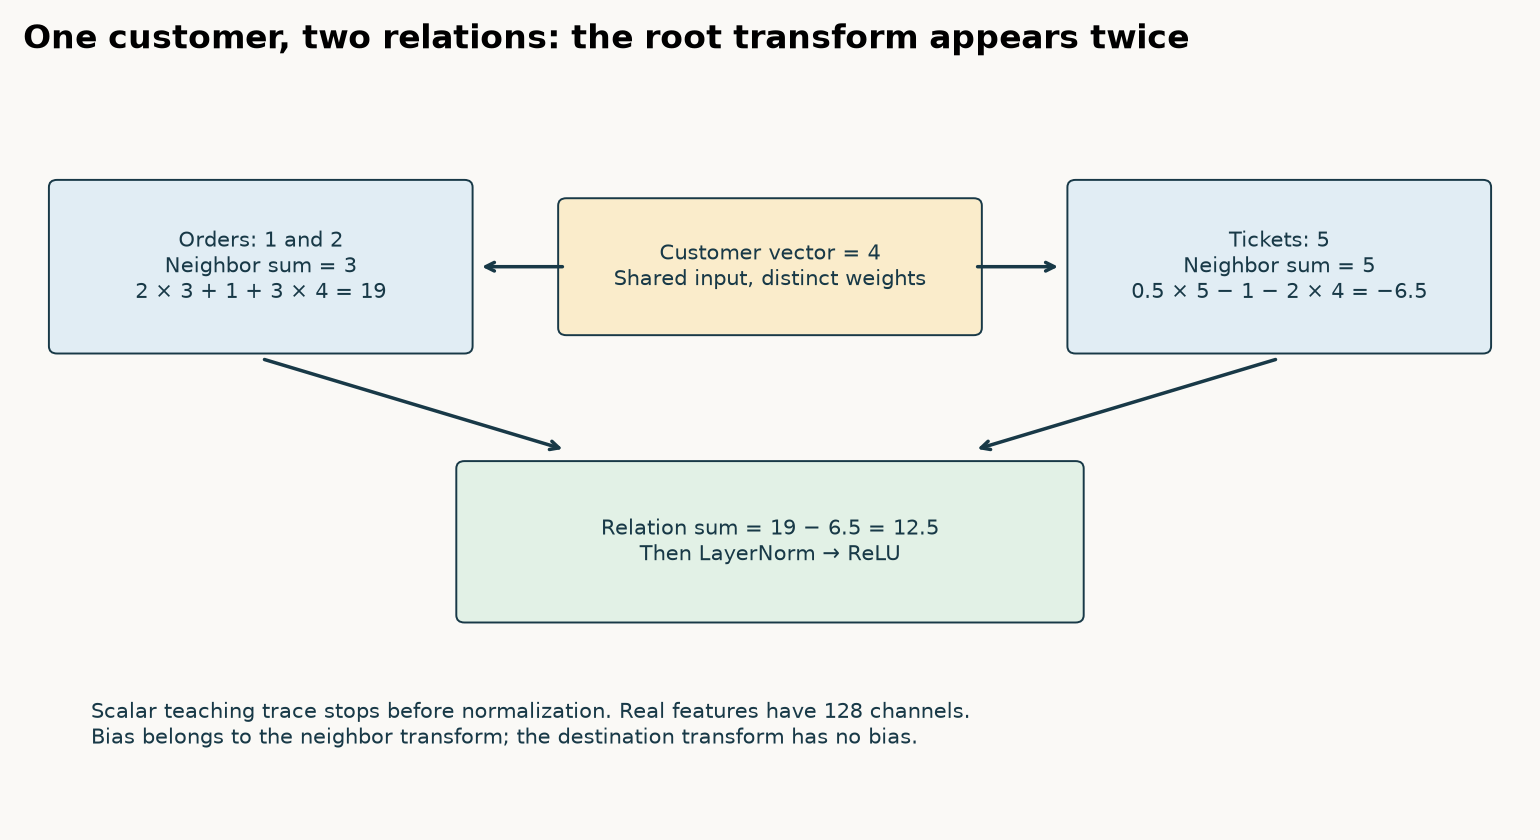<figcaption>Two distinct relation transforms use the same customer vector; 19 plus negative 6.5 gives 12.5 before normalization.</figcaption></figure>

For our customer vector 4, the orders relation uses neighbor weight 2, bias 1 and root weight 3. Its output is `2×(1+2) + 1 + 3×4 = 19`. A tickets relation with neighbor 5, weight 0.5, bias −1 and root weight −2 contributes `0.5×5 − 1 − 2×4 = −6.5`.

**Predict before touching the control.** If we remove all ticket edges but keep that relation present, does its contribution become zero?

At customer4: tickets present →12.5; empty →10; absent →19. At customer0: present →8.5; empty →6; absent →7.

**TODO 2 — `relation_output`.** Implement the equation using the existing relation module's learned transforms. Reusing its parameters lets us compare the computation without changing initialization. This visible function intentionally supports the released unprojected, unnormalized sum-SAGE configuration; it rejects other SAGE variants instead of pretending to implement them.

Implement this operation in the TODO cell below.



### TODO · relation_output

Implement the described contract; keep the CHECK unchanged.

In [ ]:
def relation_output(conv, source, destination, edge_index):
    raise NotImplementedError("TODO: relation_output")

In [ ]:
def check_relation(fn):
    c=SAGEConv((1,1),1,aggr='sum')
    with torch.no_grad():c.lin_l.weight.fill_(2);c.lin_l.bias.fill_(1);c.lin_r.weight.fill_(3)
    x=torch.tensor([[1.],[2.]]);d=torch.tensor([[4.],[5.]])
    e=torch.tensor([[0,1],[0,0]])
    torch.testing.assert_close(fn(c,x,d,e),torch.tensor([[19.],[16.]]))
    torch.testing.assert_close(fn(c,x,d,torch.empty((2,0),dtype=torch.long)),torch.tensor([[13.],[16.]]))
check_relation(relation_output)
print("PASS: relation_output")

## 4 · Second sum: combine relations by destination table

Both relations update customers. Add their outputs: `19 + (−6.5) = 12.5`. Group by the **destination** table, not by source table, and do not average relation outputs.

**TODO 3 — `merge_relations`.** Combine complete relation outputs while retaining the autograd graph. Your function feeds the actual synthetic neural fit later in the notebook. The root term appears once **per executed relation**, because it sits inside each relation module. A design with one shared root transform after relation aggregation can be reasonable, but it is not this released layer.

Implement this operation in the TODO cell below.

After relation summation, RelBench applies node-wise LayerNorm and ReLU. LayerNorm uses the channels of each row, not every row of a table. Our scalar arithmetic stops before normalization: normalizing one channel would erase the comparison. The real model has 128 channels and repeats the full layer twice. Adding a second incoming relation changes the neighbor information, the root contribution and the bias; a relation-removal experiment is therefore not automatically a pure test of neighbor information.



### TODO · merge_relations

Implement the described contract; keep the CHECK unchanged.

In [ ]:
def merge_relations(outputs):
    raise NotImplementedError("TODO: merge_relations")

In [ ]:
def check_merge(fn):
    a=torch.tensor([[1.,2.]],requires_grad=True);b=torch.tensor([[3.,7.]],requires_grad=True)
    o=fn({('a','r','d'):a,('b','s','d'):b,('d','rev','a'):b})
    torch.testing.assert_close(o['d'],torch.tensor([[4.,9.]]));assert set(o)=={'d','a'}
    o['d'].sum().backward();torch.testing.assert_close(a.grad,torch.ones_like(a));torch.testing.assert_close(b.grad,torch.ones_like(b))
    assert fn({})=={}
check_merge(merge_relations)
print("PASS: merge_relations")

## 5 · Empty and absent are different inputs

An empty `[2,0]` tensor still executes its SAGEConv. The neighbor sum is zero, but its bias and root transform remain. Omitting the relation key causes the pinned HeteroConv wrapper to skip that relation altogether. In the example, an empty tickets relation contributes −9 and the total is 10; omitting tickets leaves the orders-only total 19.

<figure class="stream-figure" tabindex="0">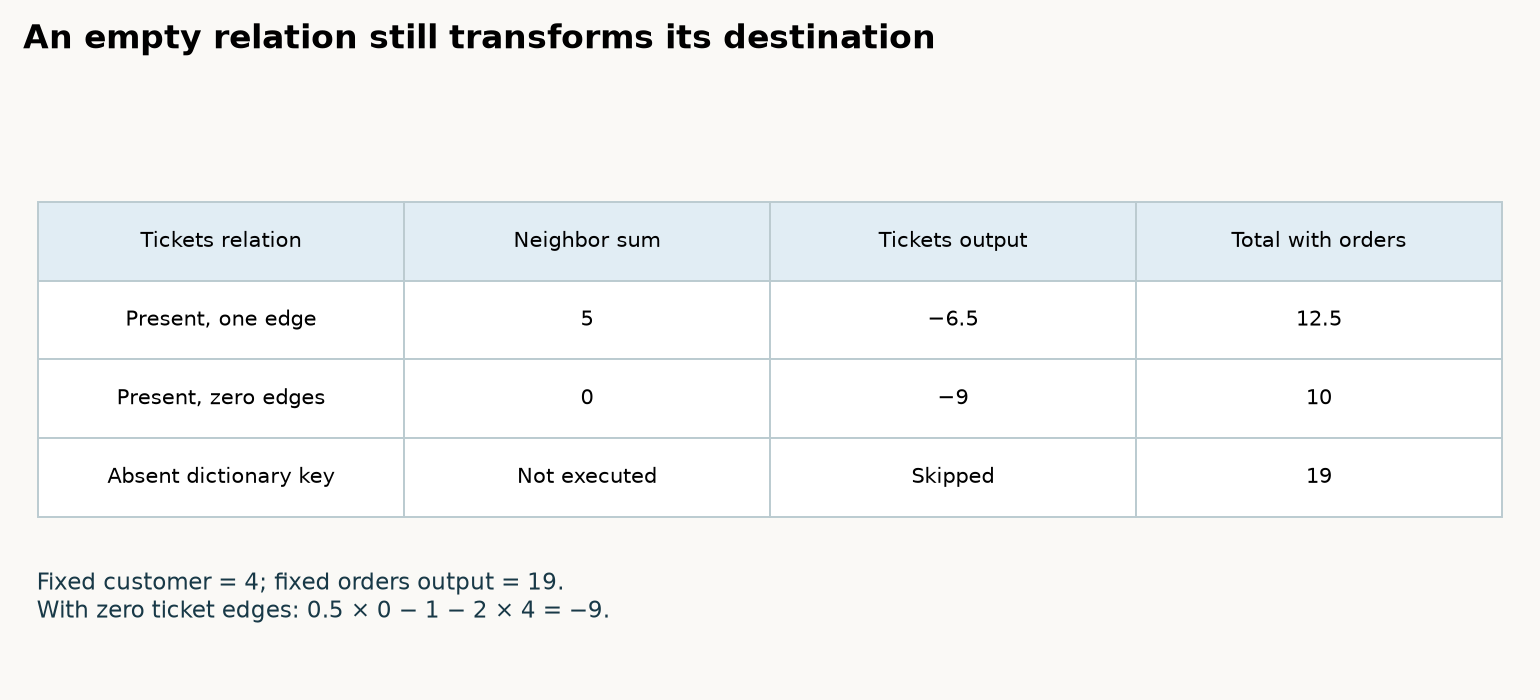<figcaption>An empty relation contributes its root transform and bias. An absent relation is skipped.</figcaption></figure>

A node type with no executed incoming relation may be missing from the output dictionary; the wrapper does not invent a residual connection. This is why graph construction, reverse edges and sampling dictionaries are part of the layer contract. [PyG's HeteroConv documentation](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.nn.conv.HeteroConv.html) describes the relation modules and destination grouping.

**Transfer check.** Permute customer rows and update every affected edge endpoint. The output should undergo the same permutation. Renumbering rows must not change predictions; changing only features without remapping edges changes the graph. Our verifier checks independent permutations for each table, edge order, parameter gradients and an Adam update against PyG.



## 6 · From arithmetic to a named experiment

The notebook first trains a tiny synthetic model with your three functions. That proves they participate in optimization. It then independently rescores the recorded real predictions. Neither step is fresh full-data training. The appendix exposes the complete row encoders, graph builder, temporal encoder, GNN, trainer, checkpoint selection and a gated five-seed fresh-training path.

The selected target is **RelBench v1 Table 7, `rel-f1/driver-position`, basic RDL**: five fresh seeds, all released task rows, ten epochs per seed. The [paper](https://arxiv.org/html/2407.20060v1) reports validation MAE 3.193 and test MAE 4.022. Before running, we retained the course's descriptive tolerance of 0.2 MAE on each mean; this is not a statistical equivalence test.

**Selected released-protocol experiment: COMPLETE.**

| Split | Fresh mean MAE | Sample seed SD | Paper mean | Verdict |
|---|---:|---:|---:|---|
| val | 3.195830 | 0.042147 | 3.193 | CLOSE |
| test | 4.170602 | 0.292558 | 4.022 | CLOSE |

All 6,295 final predictions independently rescored and checked against the original model. Every training/evaluation batch is audited for query isolation, timestamp cutoff and source edges. [Fresh evidence](https://avistian.github.io/relational/labs/evidence/l133/summary.json).

The first GPU shadow check failed its tight numerical tolerance. The preserved recovery compares cloned layers on CPU float64 using the actual sampled feature values; GPU training is unchanged. This checks arithmetic separately from GPU reduction ordering. [Local behavior checks](https://avistian.github.io/relational/labs/_verify_l133_results.json).

**Portable full-training path: PASS.** All 24 notebook code cells also executed in an isolated pinned GPU Python namespace, including five fresh ten-epoch fits and five layer audits. Their 6,295 predictions were independently rescored. These validation runs are separate from the primary result table. [Portable gate evidence](https://avistian.github.io/relational/labs/_notebook_gpu_l133_results.json). Live Colab remains NOT_CHECKED.

<figure class="stream-figure" tabindex="0">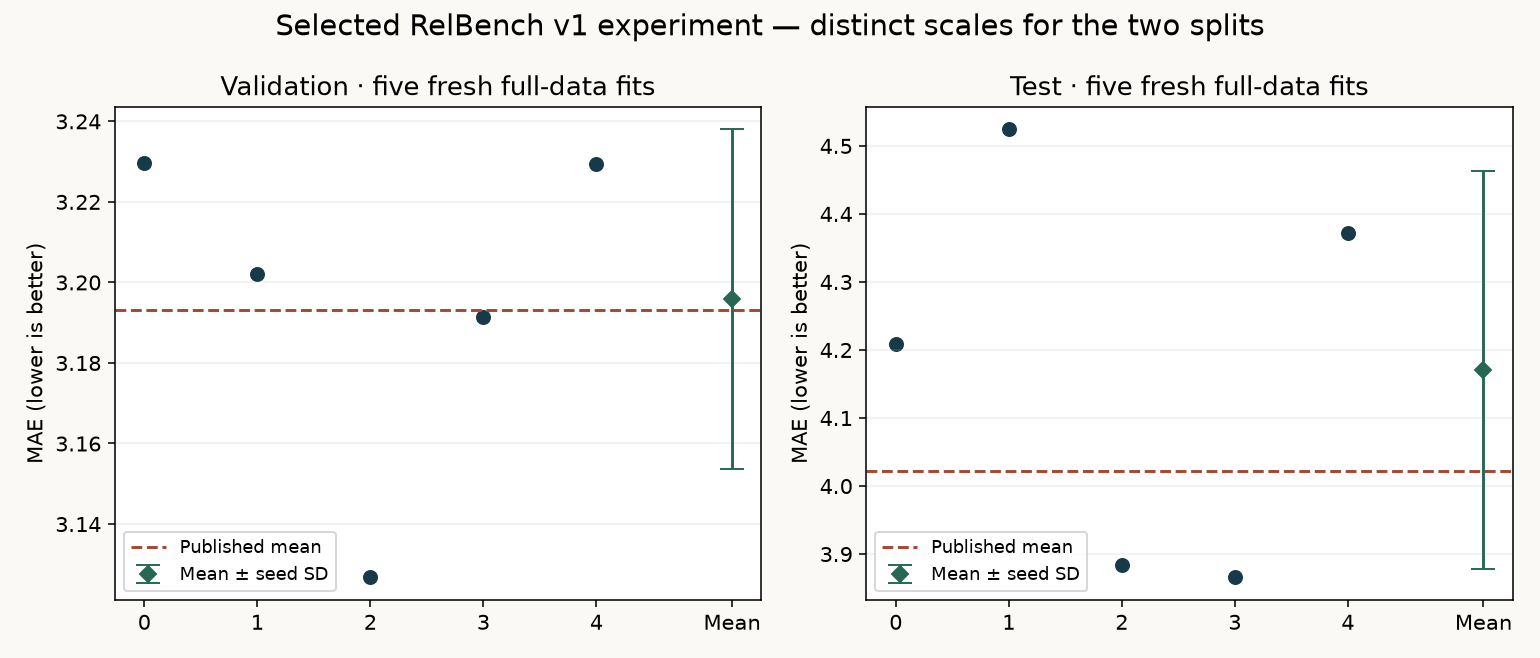<figcaption>Five fresh ten-epoch full-data fits; mean and sample seed standard deviation versus published means. Split scales differ.</figcaption></figure>

Every fresh fit checks the explicit first convolution on its actual first training batch, using cloned parameters and detached copies of its encoded inputs, transferred to CPU float64 for the shadow comparison. We compare outputs, convolution-parameter gradients and encoded-input gradients with PyG. The primary fit continues through the original operator. This isolates the layer audit from changes to the released training algorithm; it does not certify row-encoder gradients. Lesson 131 documented matching nonfinite gradients in the upstream numerical encoder, which is retained here rather than silently repaired.

The [reproduction contract](https://avistian.github.io/relational/labs/l133-reproduction.md) records exact commands, hashes, data, runtime, checkpoint rules, costs and deviations. In particular, released code uses fanouts `[128,64]` while the paper table says 128; preprocessing statistics use the released database through its test cutoff; historical seeds/runtime and real ingestion histories are unavailable. Completing this selected released-protocol experiment does not establish historical identity or whole-paper reproduction. Other benchmark tasks remain unrun here.



## EXIT · defend your layer

1. Reconstruct 12.5 from the two relations without opening the solution. Identify both root terms and both biases.
2. Explain why empty tickets gives 10 while absent tickets gives 19. Predict what happens if all incoming relation keys are absent.
3. Show a table-row permutation and remap both edge endpoints. Explain why a type-specific row index is not a learned identity embedding.
4. Explain what output/gradient parity establishes, and why a source-faithful score cannot establish healthy encoder gradients or whole-paper parity.

Use the [student notebook](https://avistian.github.io/relational/labs/0133-hetero-conv-reg.ipynb), [executed solution](https://avistian.github.io/relational/labs/html/0133-hetero-conv-reg.html) and [compact reference](https://avistian.github.io/relational/reference/hetero-conv-reg.html). Ask me follow-up questions about any step you cannot reconstruct. Read the released `HeteroGraphSAGE` class alongside the paper's implementation section. Lesson 134 will ask how this computation survives sampling and scale; today the objective is to know exactly what must be preserved.

<!-- sequence-next:start -->
**Carry this forward.** Budget the sampled occurrences while preserving this layer computation. [Continue to Lesson 134](https://avistian.github.io/relational/lessons/0134-training-at-scale.html).
<!-- sequence-next:end -->


## Your functions inside a neural computation

All three TODOs feed the actual layer below. CPU float64 shadow checks compare outputs and gradients. The synthetic fit is separate from the benchmark.

In [ ]:
def explicit_layer(conv, x_dict, edge_dict):
    """An omitted edge key skips that relation. An empty edge tensor executes it."""
    if conv.aggr != 'sum':
        raise ValueError('Expected outer relation sum')
    terms = {}
    for relation, module in conv.convs.items():
        if relation in edge_dict:
            source, _, destination = relation
            terms[relation] = relation_output(module, x_dict[source], x_dict[destination], edge_dict[relation])
    return merge_relations(terms), terms

In [ ]:
def audit_layer(conv, x_dict, edge_dict):
    """Compare independent paths on clones; inputs and original parameters untouched."""
    a=copy.deepcopy(conv).cpu().double();b=copy.deepcopy(conv).cpu().double()
    a.zero_grad(set_to_none=True);b.zero_grad(set_to_none=True)
    xa={k:v.detach().cpu().double().clone().requires_grad_(True) for k,v in x_dict.items()}
    xb={k:v.detach().cpu().double().clone().requires_grad_(True) for k,v in x_dict.items()}
    edge_dict={k:v.detach().cpu() for k,v in edge_dict.items()}
    ref=a(xa,edge_dict);out,terms=explicit_layer(b,xb,edge_dict)
    assert ref.keys()==out.keys()
    error=0.
    for k in ref:
        torch.testing.assert_close(ref[k],out[k],rtol=1e-5,atol=1e-5)
        if out[k].numel():error=max(error,float((ref[k]-out[k]).detach().abs().max()))
    sum(v.square().mean() for v in ref.values() if v.numel()).backward()
    sum(v.square().mean() for v in out.values() if v.numel()).backward()
    gradient_error=0.
    for name,p,q in [(n,p,dict(b.named_parameters())[n]) for n,p in a.named_parameters()]+[(k,xa[k],xb[k]) for k in xa]:
        if p.grad is None or q.grad is None:assert p.grad is None and q.grad is None,name
        else:
            assert torch.isfinite(p.grad).all() and torch.isfinite(q.grad).all(),name
            torch.testing.assert_close(p.grad,q.grad,rtol=1e-4,atol=1e-5)
            if p.grad.numel():gradient_error=max(gradient_error,float((p.grad-q.grad).abs().max()))
    return dict(status='PASS',audit_dtype='float64',audit_device='cpu',output_max_error=error,gradient_max_error=gradient_error,
        shapes={k:list(v.shape) for k,v in out.items()},
        relations={'|'.join(k):dict(edges=edge_dict[k].shape[1],first_destination_first_channels=v[:1,:4].detach().cpu().tolist()) for k,v in terms.items()},
        scope='Convolution parameters and input-feature gradients; row encoders outside this check')

In [ ]:
def tiny_experiment():
    """Train the visible layer on a tiny schema; course demonstration, not a paper score."""
    from torch_geometric.nn import HeteroConv,SAGEConv
    torch.manual_seed(133);torch.set_num_threads(1)
    x={'orders':torch.tensor([[1.],[2.],[4.],[3.]]),'customers':torch.tensor([[1.],[2.]])}
    e={('orders','belongs','customers'):torch.tensor([[0,1,2,3],[0,0,1,1]]),('customers','self','customers'):torch.tensor([[0,1],[0,1]])}
    conv=HeteroConv({k:SAGEConv((1,1),1,aggr='sum') for k in e},aggr='sum')
    parity=audit_layer(conv,x,e)
    target=torch.tensor([[3.],[7.]])
    opt=torch.optim.Adam(conv.parameters(),lr=.03);losses=[]
    for _ in range(150):
        opt.zero_grad();y,_=explicit_layer(conv,x,e);loss=(y['customers']-target).square().mean();loss.backward();opt.step();losses.append(float(loss.detach()))
    assert losses[-1] < losses[0]*.02
    return dict(status='PASS',parity=parity,initial_mse=losses[0],final_mse=losses[-1],steps=150,scope='Synthetic course fit; not RelBench reproduction')

In [ ]:
fit_report=tiny_experiment()
assert fit_report['status']=='PASS'
print(fit_report)

## Independently rescore author evidence

In [ ]:
# Recorded author predictions: rescore them; do not call this fresh training.
import io,base64,hashlib,json,statistics,math
from pathlib import Path
import numpy as np
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQCxrq58//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAFwcAAAAAAACdlftfzIkax0M7Qte5VLpMUzPznWka3TSpMPWukTghJKUoSbqtkja0VEjtxrrUnjg6Yt0XtZxdHezh5HKWxZZje8XBVi6LdUna1y6xcub8C+f57Xler+f1vJ7X8/58ntqps6bEJQ2yKLb4WJOxcOmCQk2YQjMuM0ijV2gy8wuLCucvTs0vzFj4v3r0/LylC831pVnzCxaac21QaKjeW69Ypfi/Y7jqsJT1X4Vj3SLiaq2BdKtRdJSruZznxeTdNiQ36ih20XJ95VwqDkfzalAqDzxB3+6A4VUtDw+Mx3tPFS7lHjwL82b3n53wHqanPTuWoKxCegZPJ26uE7uHOJOHls5KOdaiePbWC3zuZ8I/X0lauyfahHiC65ewcYoXdQEO9EUIbKrw5nGWjNfXBILjp+LYpeHy6QRaT7qy0dmdoldK9D+OxkI0lZxBGqL/cKN4u45YSzE99n6UHJMzzjUHY98sCvxV3LmUz/3fVBz6eTnvAwRiBwvs73AgpE3Mlc5RaA+PpjZSwpRXg3H01zCkOw4Lu0D+FuHI91u0vBZ50j7dEeMyF1aeVNJqF8v370LofiTF4ooveyLXELfVjxers+keKuB1RI1HqQnRpBEETVbjr1dyvN6HhF90fPNPA4Uv1TgXRvK0aTDzysbx7XMrLlb5Ylsg5f0nEwkp1OC/05FbZ+R8kSBw6qUrz2bG8iZfxunzTviL3DDlqBkfqiLPQ8PA4zz0zyfRfa+cdQVKHOVl7ApT8qA7lNJ0KYnDQmle6s62HismVqdRU6nD3mYmBRIxGy11SALU+DbpaenyoNk1jNvrZJhcxXx9XUzTeR9qDwo4S+fiXDSC1lQlW+OW0bBVxbZQAccAK95LoHy7jPjHAhXJOlovSijNtWfDR3rEDeGEXw5EYdJR2TSBXbVjsexxwclyFtdLrdlwI5kLz+H1CgO+DkaKvbWc6zSSfW8F1TUGdie4c+aiFtFXUkTRYoIz1bTdmMG4vWnIZ/viFqTGfbmKUpOan85V0tcZwNNnPjwqWU2yk4xXm9Tsm2be76KJv0jeRvT353Dvpz8ialpUPFvsTsEkCUk7XMxMjEH/qUDMehXlMTK2KdI4XO9KS6Itb5UCTdM1ZOgXUdVWQPmSUK4eteXqi83EVykZd20u8uBAWg6UUNdrg/SiJxltFuTOzmZ5l8DZ+KEo5CNJsRZo2BdDVasfXqN80f0QTtkcHab3GuxviTEaPPkkSMeYcCd4n43obg49Oi2K39RUW6mZkPoZt/5qxzGDluqdqYjMbGkP6AnZF8yR9ToSnkpoPKjj914ZPy7XEjZJauYtl/Q8FREzxdjvk5Np7cOm21Lstnjz4oGMqGUKpj0UqGvxocvfC90eGed7azg6PIua40tRb45hTcYwbO5a01C9AJdogUMPvbD8BUrM/UePDeXKMyl72wQSH8xGjhTDrx+yfEDKny77kGnjRONNJT5mXuySHPGSOhDZPpPRflpaGlwoUghcP6nijY2a1s1OfLcvi5Lcj+l/pOCc3nyPwZ/SNE9NR5aanzvjiX6SzxFf8ywnEetuF3HK3ZHAugDGrvPCIt0btYvZX8rFiNZ6Y9thx1tfCbODE6lXwKHgORjPylBa2pCWrESUOJK37wREba7c2epA6QIfZp3X0jPCke3mu+ye7c3AdjXdDR5s2LmQiGlRWD0dju3mD1CneCJKVXN6hhdn3/hiZfaz9vNZtLj58+qEFc/dxzN6xfsImckRbaBAyjk7LkQaePA1/GPAlRS5lKedgWyrNFD8WoUociTf/b6Sz6s0zBk9lbP9et7UeyFL0nBVtoA9EZ68bLTh5mcSbj+X4tdhoPyklC+r30XIPzRRsUXNqS+1fOEhsLpMje1dKf2HVGh6Xbh+W0uml5bANWJMOwJYFK6huCGGysUa7neISbilwDZEQ3P6AgbKrUncoyTHdzKPukUYKz2JqXDDqieD1v1mz3w0g9gf/OkPlRJlZrNilZKU/6hI+casW9tcSnoHsbbRgQ1mRiY0S7nUrsW01pl9blqCGpNoCA3Dr2ECuzNVDJyQUuc5k7x/yZl7bRGCTMC/Lxz5hWCy3nmyLGstF6qGUNDqQUqFipVbzLyuCuLeoAl8m2yFb4wbY4fO4E2ZKzUvR5B+wQFiFrN/j5a6qAQcoiVs1Iaz9pw9xt5UhsmMmCaGUL0tmIPrgrH/uwT9JQk9SR5s3ijjzAk1ceZ/0GcU6Lq7CcV9S4xFsUyeNRy9TMPBu2Yf1Cpo3qkhL03FxR4Z9ddyEFLGMOMDCQcT9eSeDePaMLOmn9jzZLwDjwtdmbfDFqlFIvO6pJy/kUdplDNPjD4s2etE5wsl5wIMyLao6OubQ/RVN1bZKNiVPYtfj5fR7C3hZqSSXXes2J5ezLKpSjwcSjnmZP5DUR9R/m93/gtQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEAr89Wqv//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABVCAAAAAAAAJ1WeVSTVx4F9FgFJJAgJCEJi4SEJF+SolWrFrkMWwUUZQtL2GQrsigwSMdaj0it4wJqOFU7ltFWrHaOTo9QxbHDWEXG44qOS1VUBAvuWlvqWjt5v28S7b+Tc955S95y7/3d93ufZUZyfEKao0ONw0JVfkHVnErVZD/V1MLxKp2fqrCisroytzy7ojK/gI1H5ZZWFVjHq4pz5xVY++qJE4y6YJ3fIr//++dcmdgEr14pFlQsQd9JNVTzm7DNOxStjzmc22vBjjEWTPSfj9I3fPGybiaaStZQ6fOxYEt5E/+/0YLRS31oDzb39f/KRCKog7UYOMeh+bYYTsvj4fzcgq0tPlgni6Sz4mW+GEpci9mOHBy5RmrPWekBQbkKztu1WLNaQ+vqFRIkmDKpPViVDmmdGIF7RmHPn8ywCFX4SaWC2y8RaL6QaufBMNdNVYDxNIS+iStXjYSfYWZ47x9REE5WaNyKn62ZZfSlOWxswQYRfivWYlGrGu9fSwRSfZA0qwDV30ei5ymHhI980VsOOm/VTi1MRzhI4wVoag/AjqVzsC61hs569rOYataPFeRg4LiYuDLOKQo1lk1Nx+DhYDxZMp1iweYe9eKxM0xzf5QRHr9Jb6I0KZPa9zJXY9dCbyyd3YSwIT3ePS+mNnfPQng6EvRo+EGPm/dS4OAswfMTOjwz6CEq5mj9Skkkzo9Q0FwWlz39MtLXFoczJT54MjoPWd9H4Kuf3PH528HY/k4wPA+NR90nEkzwC8PtNAmKBIDxG42dT81cM645qJH/URRMF5IRN6QgDra4HJgltXNkPgvPkhJu1l6RPQbHK5sASwaqKzk8TDGhaJQR9c85HPubDpnHJLSHblUqOvdq8cMmIya7cbi+TETeG7gSQ/Hsi5PCbW2BnUttsp44/rtRhrPDXPDtlWlIalXgRLQnjjiOxcobQajZaMY/qlWYMTEMIT5B2N+QQp5wWyghfExvG4dchYX6TMcZh7IhfE+Ptlg9Hn3KYWkgP6fZqh9rT7mioXlaqx6Mc/s1GTzeUaLrcAxCHZWEjxXLcCGuPtURh+FSL3QXR0A2xR/1G33hsdoT4WnhWF4agJ5dAgz2JGPNu0kw5ZkhrzISTqZbe74nHLbzGjI9GU4b5og2juqRc3i9GTZWTvXrkG9MgavKwMdnn5YwMD2Zltf3avCJSQjOLYv8EVIjQ09alR23TWNWK2YI0BfOYd5RNRyblbTP5MXeSI8FhqLc4XUkkbSI/M86DGY3YbKzwu4FWx56NiSH62UdYbm53KrpeD21d5vHEt7uDh6nsD0Du2dpUbfCBwanaPSGyWmPB2+r6FwbPhs2dm58XSAM/mpwEYF4eUcNmUSJ2qcBuOj/BxReEGEo1A83HijRsC8Mrcfmo3OCVZfbelrrlS4nHwc/5LD9Ae9pW6xZGZWmx68hehobtkKMssJk1Ltq8exfvG4vY+Vo3uhBe72uW3eLDu6LBYTZ/2IwHvqH4cydACz6YzBkyRPwYbsQrd8I4HTLQJ67Ui2x3xdWX6qV2PMaq1nsZdFj0FvP528qRj6WLDezuNrmp4bz2FJvyTBmZTT6ymSkYafIB70vBEiXNSHuVgH2tAngXKDBtsZg/JLE4XSZL6KuTSPe93tmoz03Av1NEgy0ueDoDBfac/hLE3LXvspzG/rUGGFQoWuJGhlV8da8wfuU4fzqoBYvW/Rw3ZtF2ApLjfBqTf+dfxlfxsX27lCx9tn8o7+J7Nxs71ZtdhRaK/i3KQYBPNb3+TfENV6BoqBEHPtOA5GTBiF3NKhx5eCwsAhOsw24uz/LjpvljfAvpSj/O6CWSChOtry+tSIbWy5744PLZlS6Z8KtQYOpc+MoLquMEv5Nic7GW5c5LHlhQM5N3kP7G3QY2+Fj93z3aRHpwPTgzvM+ZvzKR4vQc4pfw/Zi4+JzcpzfIfzdHWUaPJ7EoTuQw7V+NULSghCdE2v3/xNxIR5VFOGoVI/O1To8PCmw+y/wkYr43Bgmof1rvXJQskEDlyIVBq1n3H7sQT7UN87CzfgsZOwyYImVX9tO/k27bsU/0GB9O7oMKB3FY6W3N09hz0tdAt6PqX8V2WPO1uZskRNPNn/zlwriIQvV2Hmx8xOD/NBijd3BF8WYtKoAn8bNwcdKJbZunk7/J0QqKaZFh70xfLgZn3/mQfckZipnP6trnCcU8da46mR2zMGNetSuzKD7yvgIG6X48A1vandwSSgd5JA3Qo/dMGDgYw3c1ycTjg5lAAya6bTPWW/+XVZuckeG9a7YNJ13XAcXq2/chTIEWsx2vzwqykPCGTHG5odjSrUYDiozokZ72HEO/OpF2JkeNzfKUXdOT3icL4rxxF+P/R16mC6a8cJTj9OHdJgUk4aR/5QQhwuNOut3gDd+/NZMesyOkhMG84kAwj34ml/uWt/rBfN1hPn1HJl0yoyTGR4w6XyQsiwMa4LSaO2Tp9MwaSf/fdC4WAIXYyC49CBsytHBqTEQ474LxplmLTrfq8YHWwMR4hyN42eUkH0djgvzTMi7qsKBt2ZS3md6lbTriXNJtoj4hde84t1VJieMTK8vDL5UR22W0X8/e8uhdBbRHqzfYO233JXiCxGHJImGOPb/RYVL1vfJkluE+hwOcbGvvgMmlAXBsDoSnQdV0NWNo/msDIjV6B0pxJ8bMsnrrBzImYmBzwyEWW3NQSwXMS0Yzpb/fQOw8bMlJtQl8HxGnvW0e/tZsdwe15wpY3jMqfy70eTK35P1fbwfbXFhOWzTPiG6pXwOMF3SoC0uBXld/nQmfQN65qO+Qov7X3tgYJgK+Q80eNodik3tfnDq90TMNmdUrFfjv1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAsa6ufBcHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABVQcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIAB3wsAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIAB5A4AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQCvz1aqVQgAAGAMAAANAAAAAAAAAAAAAACAAb8RAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABUxoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAAa4gAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAHEJAAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAACXKAAAAAA=', 'sha256': '7382c69ee94782ad51b2015c8647846a313fb9effdf8f97fce35d39675c71980', 'result': {'seed': 0, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.224282808756143, 'scores': {'val': 3.2295775942270484, 'test': 4.20864985800626}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142941}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139786}}, 'trace': [{'epoch': 1, 'train_mae': 8.994096008448189, 'val_mae': 4.293112551728009, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.853549786066987, 'val_mae': 4.34305607344042, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.532196538841486, 'val_mae': 3.7862614313761394, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.407000485641212, 'val_mae': 3.707869253113975, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.278192980152224, 'val_mae': 3.5393493435744374, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 4.967780808418465, 'val_mae': 3.43859221401737, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.917096516629537, 'val_mae': 3.4344480792283214, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.897085479517263, 'val_mae': 3.240254938052986, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.827634703468416, 'val_mae': 3.3391328916122855, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.7860534865792514, 'val_mae': 3.224282808756143, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 36.028885769, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'a76fbdaff3fd2cbf73b9de20989b464a4c6ce3e37ac441cb2f8d44ed8e32d972', 'total_seconds': 47.655458256}}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQA+e1MM//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAALAcAAAAAAACdlP1fzIkWx0tNz49qZmpmmpqexlRTIdSSvm8hjAi1sdhE4xLp8ZZKlGh3ce+ES7y6ZPP4EtfNMyk3rGVR9sVyWVlKHtdWyrUo3dl/Yc9v55zX67xe57w/n7N5SkJs3CxTk1yTQnWKPntBlvozL/WohWHqIC/1wvSsnKzkZUnpWSn6P+rjk5dm64317EXJGXpjPigsIiJIE+RV5PWnw8Zubq+gqohl1jUr7JMnUVmlpsQ8jFd/VzK6yYk3cSOI8B1Ohl8GHyN0HEjNpqJlLP6FZjQoyknMF8j412pMp8tIugUl2HJv7zC6Aueg6DVwoWYZ+hEqrg9wxMw8gDSFlgYzPY4b1ajvphDi4Ia0VcriB0vZalNOf30oAe62tLhKqQ+L4J/5jmhMPekxzrruFMmRI/FItttzY4ecZ1dlnJ+q4/6XS7i6VIqQGkzEFX/SNvUJwX0GDLcD2Fy7nIrXRYTUBnFuVS5/mSHnhy1r8DzmRki5L5/C3gsf5fb8cMaT8PcGbJ5ZEhf7q7C+OQilWxo7Y1zRZdhgVyZweYoMUbHxTr4abn2noCM8nV19YPBRkJwYgYlFOaYxfnxekU9UuJZnU7RM+1rPQkOPcNNPxvHbgQRc8OROlTePR09iS0koETMmM2ylORYfDGT6mzIuJpr8agt0y+fgFCnl8FExUXkO3B8gpn63LUVXUkm1EqHzcGPvXS27E9VIjkmItR3EtrnF3MtZQHH8V1wUgjk+oQznGgmHX+gI6RQxe/dkAqc682SyKdrrf6W23wv/nfPpSDVhgkska98o+O32ONJc3XD8MRKdSEzR+AHkzrfm3yPD6dspJedBBlYPHgvO3WImh67mVKyUdyo3rGOsiClLYE2XhMGpQ6i96ktJnh3K0E/C+R4VMXJjr3o8W3JVHNTNYlHOVPa2O/Lg7CK2WzkyXJHBFt+JlP0SSl1nIu1N3kx6DX4HVmJ5bhIjXTR0lXrilWaJaHyf4Fso5uG4BNQ12Zi+Gsngt/48FsuYvcSdPSvW8eR9NMdm+rJUtp6rX4tQEoqhUUKjcjpOZp+EnRcLmHbgnRDyux+90fY4+9the9KWjZeGU7nOA5tVroT9w45YfR5nTdXYSz8K+m4NsbGBqLJWcqhqNYKR2YGP7YLkkwG9owte/QbmNfig7Sok544TKcO88LbuEE4XrsY6RMryFd3CLzYKtoe68yJhCT1GjfZ3h1OlTaC7YBhX2114uMGEzB3BbF+jJjfLiYb8FdSFFjFPHsTeUi1bO7R425Xz1N2KpE/DGfc2gyXOPoS89GXff2KpeDOC2T878l7ui+qoM7PylEw9acmC+hLsjVwjemxorLEnqdoVT3tHKpyGsmK8JVGNbuyzcqflymC+2RZF60kzwmTlmN3I5dK3a0i2mM+JsjeCi/yZ8KQhj4gCMS1Sd9pNEmgb70L7TWvKG/uEyvsefNOQSYHOgq7WVcijLWleJeNlngttQ/x5N92dk03uTIrqFY4pl/GddzCZPyrZWSjjQ4SEkz0GmnaIqOlaSdzdtZw56YyGYOa9NKDpVHNvklHzjxYxcEA5+RPCOHvwkaA4WopHrojm1DFsTA9G1ODLsDpPLs/5ICgjw6jLdCTwlCNV9uk0jp5IVVsaJ4468NOigaycLke1wJ4v3hkYelvFzC9EvN04lLThoxFvtGCgkfHzTYFUb5BzsM2bOW8KqCvWc3raU0Hh80qYPc2NrT5yKvwlJHmqqahWEVRUQlSXwH8zTWhRTOC8wwA6bjhSv3Ikz3tN8KkbTOf12Rg8XfDwM+fW7TgmHgrikHH3pf0ifr28jrmnXbDMXEa/aQBuBnds4gcxtyKLUutAwtraBNPPPgja/VJu34zBulVE47QBhLvFM/KwnOPfGjmf9mGWnYI9gpRDEwOoL1JyJEtOVFMI0gfO5G0YzLD5Uuz3L+Nc4Rieqy2ZWOzNWI2GiwGrKDj/TNA4aOlWLyaltVPYdUFMcl4AU8JKOJ9ui65mMa+TfdD02PLo8FCiq3zZbPTb29+Mf+4PX1Q9FczSrQg36iTTwYG0SxLQqujXy1gRON/o0xmI/hfDCetRVB2ygH05FH/lR+GOAtraAxmhnotMmUzKvWCWmpWz/29PhZYAMbqHXmzstKVjjg8P8+bQ1mzGO7ED6jsLsSwdyNsiEduO9QtliWuJbVdybddiNgTZ8mX2TF42m/IiKYf2u2M4My6RNSEh1DcNQWMwx2DlgipSSfVoET/HjcGicggmhRLuS8pJ+alLaNmjR6dpF2bYRDC7T8beBy4YdimId9XyaouITebljBqrQzxIzPdto8ghju9r/Pn96SfBPLJfeDHOilOjbIi/lMa1zwdivSyde2ecqYsZzWadNZFVgUSujycm3IPSQSnUevujOCjDoTWHhyllBFeaMaMymqTmN8K22jKefwhhw0cDfcfd6NWuJU0k4f9QSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEABRndxP//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABgCAAAAAAAAJ1WaVRURxpF6deI3USwhwEEoZveeN1N1KPSEVHfHYMTNLiCgIzHICBwgG6CS1DUEZW4jaElzlHiLmYSRBC3jDijhjMas6ByMJpoZBE0Eh0lBBDbJc6rKl/H/J13Tp1a31f33u+rr+rDqfGx05P6uS1xKzSmpS9MzTdGqo1RC0YZLWrjAnv+ovwU2zx7flo6GZ+UkrMwXRxfmJmSly72w6wRwy28Rb1C/X9/AxuHORCxiEO9hwOLHpfAZnDg3rMSXG/QYaPJgclBDtR4OpAVosTnL0ogf85Kc7D43wg23zPAgQf+zAZZ++rciRgOmlINrs7gERHeLbg9KcFWtQOR1UosPjOD7mWf4gP/1xxoSdbhqGibtIM+bhP8JliQvFmN2v0akP+Kk5WwfZtI2wc9E1G5UolzPXKs7rRhs3cYmuy+OLwtErmZkS4eBPPEUwoQnjVWE67s5Cl+gpngHZbYn+IkhYwT/OSfdyKUdA0ZKy3icGwajyHv6zGuTtyrnMO76wpx0SMNyaf0aPrFBzEPGBfnzxYs9tKiy0+OF1F+SF6/FKXiONnLL1ZGa9KfXV6IJpsH5Uo474vUQzPajnl7/oDAiWOpL8ja9jyOYieYFvYqKJ66VAOO/TWHtsfLHVh76ZEQJ/qq/SyPoQ1O2n5Tz/irzDyiu3QY+Gc7DL1O4WyDEUEzTagK0dD/HTtmQp/sQ9cSv6imeVF9JT/8c4UMUyyFeMM7FZPmyeFcYsE+lRZuoyNF3wzGgY6Z8N2qQvKsOGyr0rn4RDfbEHPBH9m3IlFUGYkN5xWUg+SXhHq5iyOJsy/WPKG4SdvtZw5DRH+EV+ZieJcegyZl4+lDPeYN4JH2bhgy23oFYuNJRx7OLtPh2pcm2L/RIetXGY29t8V9iD+X7uHwaXyhi8ul5TrKsf6/SrwRx8GrOgFlY4wIOemBCRWvo2p9KN7zsKPvJx1Sc8ejpkGFlq1RNCaCm5muRG+Jw70A1ic69oXnYdvrelzM1KA1QItRWrbmhKJHIO3agyzu0iypjHMOh/vn9dhxPgErkodSfKQcn9cspEwMoRyCygfA2C8Rb78fhofbwvCdhyeinEkwHjdh85kWoWnEWNw7Z0XNrFzUHjFQnES3CbwcZ7qZhkRPglPC3OcWQmv5yMeUD8FGinVlKHj3HJyL1tP5H/I1FAPRk2jpjOVxeQOH6kp2/kJ/VGDJIIcLt6QxqQtaW4WuK3oczgxEZwFP7bjn+2C0dRYaBrcKd+qsVIsgUYfVggM/PJK5YkHKQ+5eMsz9UyjFcr9Rg3Klibb/letN8ao+YXMzq/Kxq06H2JVO4a2p87HewvLQKR3bV8InYSP7Pq8ZgsxCLSYoLOgt1+HqdjN2ZZjhEOagIskTZUoxzg754bMN45BQUYR7VWOw9CjzX3Yjy4P712jBr2Ztydek7F2rQecwno4VlD4Wxmy3w3eIHvFHmG5zBitxDBy19apuC4Ya8Py7NoFgvns5GNZvZiPD14jT8f7YK9qd49km9FO1C7XHtTTmCsK7XOeF1BmjHgtSXiM18X3HXA5tL3MyKWSO+JLkZuJXab1Zy7DVr1Ni7bP5SP2Vabjx8x7h0CYOuxUOXO5vQ+eVNmH8cD3CnGaM+WgoOm/4IPoky3uN7gWodKZg1d/6Y8VEOTQKD2pTW5yI9HNKF9faVTrc2W1AaqkKmVXj0FTO4pTg/Npbg7ObDdh1w06xvWg34Kkq93fxS/gSLtK9Qwrpk/WTu2UubtK99feqVBTVsLxbl+JNbWzpTqDY4lReeDMgD3/J1KP4Whh215vhu0MDa4kNOau0uFtpc+EmeSPDX4lLZTMRmO5DY0vK68KHhZhTLcdijR3e5XakqvwxcclY6pfBgX0CwYEIO6ZV67Fvnw5HNF40bmJ9QzG6Uu6Kebf/MH8RPU7eZpgJv6OVMjTeZLFGbJHxgUFyxC2R/e6MEg2yvjbBHBOKNUfV2BRuwL4RSa74T0+2YdM4Gz4u02Hycx3k/W4KUvxpxpson19e4tmTsgxdPwXgyI8BdA91RLtA4jAjPQrdN7PR862e8ts9q1uQ8J9c6w6teE9+tYhhJSVbfDcQzP7kLRDG+MWO4mi/7eV5v7iVw6MB7I47vJ3dcWVizrtJcnkQy+cjO5jvvF+z4/RkG0IVNng4DDjnk0Tn5z7jqU/t4r39lXjWRl5tEcg5SdCpXXuFiHF9egePvKkyl+YN7WLO9s2h55XwkXNPhX9v76Nna9NCO3TL9Li/isdnezQIadXhhd5OcYRafdB1No3aaSyUU8x+TRx2Kn470+5P2X2T5abEfO9EV7xc1RSgK0wOw4w43IhWofhLGz5Y2ixIOPvFyukZJ3pYDUoUi28nguf7RY8EvpgHFxqKQrUdAWI8mWbrkVuXDa+3ntB75vv9YViQ3ivcusRi3NqtpBhO32b6Ea0kXW8dNKM+LZhifjVHXu6wwdNbjveuimdz+XzcSV9K/80onAHLOh9q98JlJaauMGHKR+F4fN0AbUc4tqzVoshswINPivBOsQpPZ0RhZYQvypaPxwHxTRa43BetT6Jo3id67TrEU9+Yxfue6v0PpyDx9o1XUoxErwMPWUzu/aM7nTsSI74d/VgOJf2RfQp4nOwRjsnN2DtIRzlqM3l6P32aYUOwzIAtSTaXXyrCjdg+IBElm9Q4ETmGriflzo0h+CKmTbBes9GcS8rhCZEYBRPFTHNQAMtDBKf0BiDjF6bbkRVsoHyKtnKu2I7JcnfF36NOGcXc8oy9hT5oZrWzl8Wj5BeSw0qmc3h+2p2On7itQ/O0PLQMZ+80YqPW2wb+kBY5G9uEimAeDaZA3G2Lx8795B3ggaILHK7f1ON/UEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQA+e1MMLAcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFqBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAH0CwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAH5DgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAAUZ3cRgCAAAYAwAAA0AAAAAAAAAAAAAAIAB1BEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAFzGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABziAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAeQkAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAALcoAAAAAA==', 'sha256': 'e1f9562368829ec846472e32d26171addf752cc956fa9fca76ea63bf67edc309', 'result': {'seed': 1, 'epochs': 10, 'selected_epoch': 7, 'selection_mae': 3.2024450956381556, 'scores': {'val': 3.2020672798793797, 'test': 4.524176567981118}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 143021}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139803}}, 'trace': [{'epoch': 1, 'train_mae': 9.060951831627737, 'val_mae': 4.321562456909466, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.850294769074186, 'val_mae': 4.426898515327979, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.569977206382818, 'val_mae': 3.8528318028013624, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.433159826010741, 'val_mae': 3.7316903546880544, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.383386900548757, 'val_mae': 3.6640199648513745, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.276253967689505, 'val_mae': 3.270902141604172, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.943626677447736, 'val_mae': 3.2024450956381556, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.913107726456542, 'val_mae': 3.3515964383193473, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.868534652367544, 'val_mae': 3.2595958608424733, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.784189788092068, 'val_mae': 3.2161776529285375, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 36.136960178, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '13d89f176207c340b948ac0bc89465b6ac8d6ca9f8d9431d206ceefc0e247259', 'total_seconds': 48.521443986}}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQDxjXja//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAMgcAAAAAAACdlPlXzokex9tr2pOeUj1P67PV87SLFvV9NdooUZKm6GmT0kJZppvspBmjsox94rrEieOikHu7dyyJa6xdCYPT0OQgNEZji/vcf2E+v33e53zO+5z3eX3eGyelJk5O19VZqFMlz8uvyC2Xh7rKw2cFyVWu8lll5fPLs0uzysrz8v+vx2QXV+Rr9YrZ2XPztbsiKCREpVS5Vrv+6TFN2KPLtp8nYMsj4Z0qltevVVQPKBFd9sRj0mvBpNeXPYfUyJzyUDbHsb4mi81JkYyO0qfXu4qVohDc7y1mXYwtZqFjWdkwkg6dIO6dSSS9PI/rr77ipcaEzsXmoFRR80nBqbKJSC9JSXk4lc+2Et58cqasIZ0jJ3NYYu3CjnsmNB2UkqHnS/9BG9zOuuCfnUutrR87NkpoQ0zoR0McVzlxf2EUNqcyyJGKWRsnZ1ykLwMW5hQdyqb70AjuVpXwwjOL3pvutJvnMNDswqULFRy8IKEsxYukch3sl5vTlaBG3agh7KE+mcoe4dx6JWP2zWD2+UEh29GaK7+O5ra/HbPijBmSevBvYznpMRksrw+gbrcRXeHBnH6hoddTTa1PCQUzpcQtlXNl/GTkBTpE/ubMnW1SOs9LsNnpTV1XPGXrZawWTcTh8R3hd613T/HvQkVnENdV+tTGT2HTGTmXn4to+UVEZ4wzxSki+qNSseq2pfiUCcM3pdgmeWN2W0yaUk7q30sYPjaNlNGVRHR5oJ5Ugav2bteyOG2+BkxsjCBqvhsHjZ8Jg7F5pOhJqb+VRMQMfS7rqzjgIcEjLQSHShErV/nT3mpIyhRrOucYEPxdABIrCd92arB78FTYsUZCR8k8tru4cNlOTNPbJ0L3rCRu9xix+biKLy39GJRYEbJ/WBhjJufw9CTUH8Jw0ubqlJtCjXo8HetdaJoxle2LPgrXOrIo64rEsDOUracTaRz2JNAmnPxdFYzqDMHFU8bZIAUqCyMSCywJmyemzzCeFr/JWPSMJjTXk5WOEvYmSDheWUXUskiebvLkxZRSXMca4NbtReFqKfjHk/L9FSGzqoAHu38SZvxDwY/VIg7E6RM2fSSlrSpaipVsLnPmmI4RkZtzuOFqwcMCc95XapndpmBoqJRborms9Mrmi4sDgmVuAUeWOLHXMJfA5gCqKhdQ1DUk3M/3pOTSNeFIRT6+p11YlvVAUE5w4L873Iifkcbm8lwS9/mx50M0Y+76Eb3Xiea/WNNUo6TFwY8OhRV/3ChG71gp6Q1KjmUquGCvoDe+CO//6LHFSkpsZAZXchR05aoI8p2AvVkAU+dac6PTmwmtNlSKvJjZZcDRF7PZP+RGp0ifunMOGM4Wc09tTKRjAJcsjXh+0pb+VjmGXztyWBnE7WBLsjPn0KcuIvvtXCzc0wgZ/CTUp70QOszySO1x4ttkMfqmCaQOGHHiYb8gztTh6Ed3zr3U4P1Gj2r7YnoXGLD1k5xdZ0YiXSGjY6crCS12bLh+S/BNnUlztA+tWn7qk90pqHak/YKGvn86UNKYR/39eRhbuJE3bEfTmmRqejxRGskZvpdGbXQO2d+7krTpufDoyRxO9ehzIjeKdcke1HVK0R8l4+04Xf5Y4INg9l6Y1qfLoWYNP+0H8/NTUI5w43HgZyFF2yH2K8RElGpYvdSGV1m6PHofQHViIFcP27LunAbTc/bsq5exyXQUbruLUK6ZxtXCAWH65SHhVoGEte/EZM1xojMimHRLBbZrZ/KuIYBp718JR/1iGGi7KWy9b8x3XirqWj8LeyeEYrcokdi7Nqhijaj7IgaT44E0jtdg/8qemAN59N0RabPI5P06ZyIfeOFyWkblySyeFbow62+DwmLjz8I+fyMK736J5KQhy+quCad2JtE1TsbhEe4s+cUDTaoLog02LHdTcHGOmEKt1jZZzYmv9diVL0VcLWdvRyYPkoO45mxJ70571CoZV/1KeFw8KKTpuRG4dRrF198KSbqjWGBuz5azecR6m7LDYTrBIf4kBlqx67YPId/ICNOVYeXiQTH5xE26KwSodTE678qSHwzp2+hIzQhHpKYeLK2aREhmDDHKMNLafLj11Jp+WRaabnt0FxZRFSrDwCOFjIgUHm0R85U6j3/5/CaEVDrR0abEXvsXkVMDif9rIiePPRNW9brSdDoNq2B3xIHPhTE39GivKCDsvidq/yTefDBlw/aJbLihS/bPGvpXhXNxTwIfysbS3jaOrlIjojv0cLpjx+PxltgtDODaDxIaVngQnVTAmtR3wraGZLrrXwpPtFx5FLqSOtmBqf0y0jsUVLcb0BeWw/LgGNqD9bje4k/a6wTayhRsKNalVutbkSyh/kdtv1/M5Nf6YaExayKBJu4Mpvvh3e/I+W/kPJZGo9Mh4/OhKdQ+c8OiW0ThuAwW2c2n2cqSlPBwzmr5HPWolOg+Jw4uykVx1pmwo/M5EebI/wBQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEA3VHOu///////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAACBCAAAAAAAAJ1We1DTVxYmWjBBA6goQnhLSEIePIRFq+jvAxRB3hARESKQAAqCggOrFl1aXWwdy2qsq7ZKUZFRrNU6Fa2Lrg+qSGullrG1Ih1dpNYHggSkvjb3pMnafzczd+7r3HO/75zvnl/08eq4xHSeVbnVGolWV5ZbKnnbUzIjL1ii8JTklZSuLM0u1pSUanVsfU52UZnOuF5WkL1cZ5xLQ/8SoJApPCs9/++f7ZWqdyE6YYf39ueg1jcbZfM2IGmsFoufSrGqaAX6tq3AzmX5kEjd8J2PFkut8qgldS6Br+8m2nf6RwG2RNuTD2b75l51lxWiymUQ1QRiOIaPPdJctD4uxZ77Tth9Lp7uEuc7YvTLIkR2KvHuIy2Nl2cPcR0HJIh0kSHa2o/ORdo6QhOQROOuukRYj3RE/X4DV7guE4Zbvrg3LMLqlhmIck218GCYxX2uYDz3e02F5J2phJ9hZnjFOQ6EkzW2zvCzM42z3ciGraVe4eFwfgAET3wQdi4FAmc7VN7JRXSuGt0XlejfNQGen8yl++p/VaKySoK9Ts+52ggfvHMzF8n/0tJdrf8ZTT2bVxi0mKW1Ja6M86k6KTq0WZj+jSdiumZTLphtnREfw84w3bojIjyVt1SodFxI44NZOiwrF2CnfiNWF4RAnWBL48veawjP2DNBcFb6IbV6PuSrBGhLD8QepyBUJ8jovD4mDu3XxpIty0tr2ySKrzkP8BkDhwoNgnqTMM/aCpdsFahWiTGtdiYGrO3w0iMOSeH2sNXEYvMCuYXPyrezEC52R5cn8DwiCYa/mvRjzkt8i52FI9PZrgITbjZ+8NYoXHy8Dm6K+TAcVmC3fwp6whVY3zUFpyYGw+ZrPvnIm7wAgnoJflIH4bNhKSpOjCDteXRqKZ/2+UIcilti4fLAR0Ecu/2dcXpMH3fXay542ZPg5D0G9/fIYCg35vdkFoRxvlArwqCOcUXdqBTShPIan/CxeJs59F8ooTmLY29wBh7flKPVUQ6PKzJ8dn6tKf4vBDRuuedPdsc81cR5UpEQ8uue+GltLKbUeBM+1jo4A1eXGkQcUiVCbPo4HmVpLii76ownE4RoKU5EHc8XCn0/J8tNwKXLcUhrWYCK1/6Ek8VN/Noavr/Z0JjFk+E0Y45apqDey8ukGYaNtaxoKdKbU5G7WEr748/ICQOLJ4tl5q0ADBzmYWCD6f19fdQZGd/rLLjNMWa9ZPogV+2vQnuMGIX3ZORn84+20IXFIjxtgJtyMJ5iYX8kD0KHasytsbdowVyHUuRjMZyoJCy/PvHD7GshNL7/YCLh3epu2mvLyIBXtQ/a5giQuS0V+jhTLTuXbMJvxmfGxu69dNMTx99XoL3ZB9tcJKj9UIoLp33R0JWIsyfHILLDBZGfuOHBnjAcKS9C7c0k7G4IpbMZnSLS8WmtCvUFJk2bc81ada8M10cH0trRVht8XpmGJdt9UVOZSnGbPE6EsmIr8vVm3Ipz5Qg/O8AxzNGbA9AkjsCxQg+EPXNHrmMOLv/+lDv87wHu84lK0tzOOwLLe2F9/22Bpa6xnuW+bu1IbDYUki5YY3ssl6w2s7ya7c/5qAnbCFsXFD1XQ3hVSDHsGyPAdbzk7iir8EvMYkzyf8pNt5Hiqw+VGP5CghnqCSjtMNW942PjYD01EXtLbKGxG+DCpw1yzOcc2wRsnzPewnUoWYpTEWL0XHdH1I8xSLpt0inDKX8oRWO6P+zbMwlbqIc/zhZn/Em/xNfIxfzdYY3NSU/7Rli4mb9burw0tOeb+Cx/34l8zLqcQnyPuYow/rdkFP3ui5eO/phtr0KYQYbLZ3Nw9pASIQFZFtysbgz5OUHXEItZnkLSlrmuT2tajJ40G3zakI19CRp0JLliARdOedmRwSccjUMZmLZGgY5AGbpKTbqJuqHAKoPQovns70z5YvG4usSB1hk/3V0eKrpMumO+2HqDiwNqVbw/vVGK2YlAPImT4edmLzz8xguPZiVa9B+3NAdT3sqBfp8cDx7JcTL0GWfW38JVciQY+Rxs56PK6L/ppQYpuyej6bQ33I133D75lGM6DExMQOaqLLQa/LHDyG/RGRuy383+O3xqjzxeKL487IprRqys3bd2t9SlkAUmfs1GXZpzzs6eiRUST2b/z+9N37jGZyri1W/kxe5fWexIudsbrcWug4txMVmD1mgPNN1Npn2PRilqjTndFDweZ4aTwDth4BqM7yTGxs9y1/E+GzjnhkIQaW/BvOmqEh/dS0Gj8b0yPscMfGhS+DSWGVKgz5FBWB+E+o1SzHQRozdqPuGoU05A29E08lPVa0eYrRWv6a2YY9q5wY90c2rQCT+8Sqb4MvsvPRbh3k0+av42DxUOdjj/xSJs/WiQM+N0b+aDYWfxiBhwRV50COFZ78bHt83BmB2hQPdwOmpf+KHhkBSjQtXQHeUTh57qQJTr+fj7/GSKx3a5iDCcvzORcLv/oRcW15JvVbixRQaG+c0aWe+ngT6Ah0O3R6NInQi3wTQ6q26di4LH48hvZ7Ij1p2XYOkPUugSpJh+WoJzj8W4sNUP3twyyEa5Q585AysCRdiRNxMpJclQt7giamk07I6Y/kNO7gmh3NSMsyF+Tzb+j3f+KxFhZPHqHuFAvaDYnvYezhRhrdsI8sHmQ+kiTL7NR29fAOy7pcTxmUqOLOP3qW1lLi7VqPBerMaSl8Iob3CT4iDpVmK120yyZ21vpxiv+ge5DwyZVHNZ6xgXg4WdoYSZ1aA+Yy1isWA4Wd/3R23Sl83Hiw9UxOfhLmuLtvcO2Vn0t/XnkYR5fZQb4a6aJ6J+ywsh2ZrzwmrYgSIemoJNvG8U+4B3KhU7ak31i/koWapB2i9+ODDKwPXF+6Er0BtresLx9KgLCoNsoXXr58IafPFfUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQDxjXjaMgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFwBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAH6CwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAH/DgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAN1RzruBCAAAYAwAAA0AAAAAAAAAAAAAAIAB2hEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAGaGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIAB9SAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAQslAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAN4oAAAAAA==', 'sha256': '116e0a40b2bc50dd3cea4df678df2fb3c08aa16ae4ad25c798c7b6581d6d9f81', 'result': {'seed': 2, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.127373263194072, 'scores': {'val': 3.1266915658990304, 'test': 3.8835766599889383}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142996}, 'test': {'queries': 760, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 139760}}, 'trace': [{'epoch': 1, 'train_mae': 8.876267491899432, 'val_mae': 4.245883876160932, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.8403232946949935, 'val_mae': 4.327545297759011, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.535225464260276, 'val_mae': 3.8725545757041426, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.423807319404134, 'val_mae': 3.733103825525196, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.380155909674033, 'val_mae': 3.645251610347567, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.140792784875757, 'val_mae': 3.242770022237468, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.906766330765571, 'val_mae': 3.244734824046184, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.841520202666917, 'val_mae': 3.207627621155703, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.845671621949884, 'val_mae': 3.229613711790953, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.762081167097461, 'val_mae': 3.127373263194072, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 36.214982144, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '63e62b85ba1c28e86310630c2fc20fb0c399f6a9ff1da78854ad0552cf76ed88', 'total_seconds': 49.428719574}}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQA7XJlm//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAMQcAAAAAAACdlPlX0wcWxbMAsSBbYlhCgBgSwuawWo0o+X6MKKtFISwKIjuubI5rEVxQ64CWKnq0dRCXUWZcitqiUx0Vy2DrVlvaqbZWqyId0UG0uFXrZP6Feb+9d8477913732bJluSU7LEooWiZYbCoqqCSsMYjWFscZQhRGMoLqtcUJk3P7essrDof/WJeXOriqz1qtK88iJrHhBlNIYEhmiqNf932C9c/UaI2xuHZ+JjwfXOJM716ojuDubkDR/kC94IkypCmaIewfXyPJ63m2krKya/YxxHWqWMv9zID+2jWb5kJYVXFDwXR3P+nh39skhsyuMYZ7DQq8jm9YAzOdUOLLpooDU9kvhD89gT6IfiaiamZDkHng5DbsygbEMtBy9oyNwtw/GEmtzUUKb/VUHkF15M700j0S6Krih3ata7oNVIGP2Vkt/WxVLjkcO3lUpuJ0TwwWF/FF5SjjpZaKx3x7k5j9ilcyhtMWBOncfu+Sq+WFyG7U8Kpqb6IY8TMbjHhVdf6ZFWWDgbJUXdc1N4lBFAlzYHj3HPBeUzOyTzxyDeNozUGFtsVgWRckzD2LU5tDmDMGMojj+OYn6YhVqlnh1b89jZEUDw9iBC6zNYtHFAyBruhvYHP65MVVESrSPNMZa2kkBE4jhOV/cK6mILCXsHhGtWDAd7JWjr43jhoKb3rgff/e7I07HuXOySEZyejeORtzCHO7BEFE7XLB2mBgWhxTqCR5cwpSCLFZJasryC8C+pwPZXBScCYli4XcLrHiMr1imJ838guJ7MoWu7Lxs+SuOlSUzK5TBq7qhodTahvCTn3OoovNqGYHhlyxNvW/YdHMnDVwr6w6Zx0vxASHVz40DLbHqUKn5eNYzjK58LRTuT+N7kwKEDIYxJNHD/rjNfLxbhssaHsr44Cn4zMTnQl7aWSQT/Gs/Qu0ryutKZO2pQWLYlnwuzQWYO5klcMkdO+LF50xjGlFeztnsC9UOCWIEvaz+1IfqgDKNciZCQywTjeMJ2j+FeiJbhI93IPevO9a46/pho4p0GbypFdSy3Yn84xUDjAl8sIXEYZTcEWUkpQS4/CbYr/WgKcGLwlg1NN2VUNP8Bo1HF9J2uJEwYwqIP5lEdqsTbykn6eR0FegM9CUW07J/DQcFCh2+/IHWqJdlJie+LNK7aB7E/pJo7Ka+F6Hof8utuCtUL5vK24MGG9HtC3hpv/qazauAv2bQtSefU80hMkUm8PheBMtwT71ZbGkoi2GNv4JyTIwMrC3i3tBDVlgD84gOpPxOM2TSfrm7rPn16klynkftnX+6t0lHaFc/hS+HEdsopOq3lrFrJ1kwfKp9K6dlUgHe9J+/V2VixDSUx1I39+2W8OB+GTZ8N+9YqmDjNDfHHGqZY7y57LaGjopEVTbl8k11BjziTkk/6hSrzfWGJwyzm/kdu5d6D4NOJLEqw5x9ZT4WYThH6L32puZiB3yMxT74u5BeJlI7pagL73bjq40f1eBXvaNW4+N8VapflUNgfiNtFDY5zvNk7R0HyMgvj9Y7sCpuFbesSRo8bRs4VD76v3UyTRMv7PwcitfZtnpxF67ZAYl7cEQ6sq+SkWsKHjjHklhvoS9NyyOzJfbOISZ+GkN4uZVnEEFZ35+HsMZ7BtDSMb8m5UvZM8K1zR66VWz1qIb7UAZWV5whLOM0XRpH7pVUTf7KwZdAbmUnNwPtqdhfl09+SxcZ5fUJ7eZ+Q1eSCqNyDpZM9mFgaiGJAw80pmYjDwpB1PhJqcmLZXnxTWN3sSPzLMApKxFyuD2Hf48mc+n0YO/4u5cTpBJ5V63nWZGHHoAPd0rWsMSuwa55h/b1aSmZ6YTiq49Z7+ez6XEfnrodCmOWNsHSWPROdx3JsppTbwk1hx754XLNVzHrojs1CLQ3f+JD5mSe7Qv0pVGg4d8KTnuIQll2z4/DHARw1epGXmUviiWiMSRLC73qR6qrHMrKYCTEPhOX3/Gmvnc7T9f3Cqs+U6DZ5smL2PMKs/0cfnYVPs87qMxfCfxxB224NI/ZruDpERcsxC05lt4TZkVI2jvTgdY0d5lwFpGq5LdXyJjaf7JQEthwQWN85EvlYW964z2SawZuK3XlomgIILM3AsD+T1oc69J3ZWDb8IoR6q7hhGc63Hc503whgRGwCnQF9wpwGN1Z9nmbVmRsDogfCLYsY463Z9O3yxvxqBikSJ4bNS6LhiIRTObMJz7Di/S6ZRnEQRVVhNLTb0NptR2+LB3aLpQT6RaNJs84xK0lzrmObuF/o/2cmVWt6hYHoUP7d7k6eyZV/qVUUiPToRBJOSiyc15tIOmPDVc9IjntNYuvj4dzJEvHkkojCfXKeTXgkRATkcPGjQaHqOjRec8a5bhRTpC58WOPC208TqR3ny9y+UjRTDdjuUXLp5Qy8VrxL+XExGaFwaPOA4Bi1nKPWub1DLUg+UVAgqeSMvRv/BVBLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQAthxu4//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAHEIAAAAAAAAnVZ5VFNXHg4gJMhWEpDFJLxsTRDrlgDi1vcNtSqyOTbKS1BUwFHBBalFtLVyELRSUUCnamWoYxXFURSLFjgotT123NBxP+Pgri3aVgHRHoRk3r2vic6/k3Puuffd9fu+33d/NxWJ5oRkzkX0kWilPiMzN32pfhSjHzPXpB/M6OcuXvrh0tmL0hYvzcgk/e/Pzs7N5Ptz581eksl/G6Kjhg0OH8x8wvzfv/7eV8rh93cJDqaZcc1ixvqIMux79AE+DVRg+dRypARuxKj9OWDUMjS7mFG0ZjotcUfKcOaZMN4Svw5JDz3oHmTum2N5D2zsue0KmI/rUVImwstrH6B10SaEp0sRtTKenrW4xgei4jWQRmpQUDCNtkdonrMDf3obLh1hmLdMTdfJF/qDkVpou8THii37/bGwrIftKOIwcg+DX65LMdJkxIUHJicPgll8SArCs3SGDpYxOoqfYCZ4b+/woDhJIf0EP1lTIJLROaSv96GN3V2jxfleOUZP5RD+vQdWF2bi7CUO7/QxOL7bB9mJApdVMw3ozlLi+r1edmJ5MPSnM9DuZaZnbZG705p8y/j17lHulCvhbF+hhu+6FER/E4isC0YaCzL3kwwxxU4wbfhQSvHoO5SIGGil7ZG+a7F2uyv21JQjaKQOSbVCe2Z0OcUzul6LhV8rMKfMgtQlIsS+r0XVDT0GRWno+vsX4lFb60PnkricyJFSfR1xGLpOjN+3Z2LbbQ5TB/axN2bpUbAjDDGtMSi57o1RU+IR8ZM3emPjYfxe7eQTez0FDVUBKOo14uk+E3R2KeXgiEthlcTJkfhMclXATdrVU0WIelGGoi+sODxJiYq/cchPUQL5OigYHVatt7Nkj73ZVuyNU6A5wYB+y5XIfGFjifeeiM00niWRHjh/N9PJpXqohnIUZ0gRkfCKvfdeEvJuhKI4WwKF1oBLngx2TOHgtUSNq1VGfNs5ADE/m6gnSn93ofiI3g4OGUGl9JvomN5kRb1ciZ6vlLi2SYMWL0H/rnmutB3RqKXzkuo4ytlWLsbJVDn6uydhpd8Aio+UBac62ILP1JSDvVKCL8ckoagtFJ4zQtF9VILu6GSMD1LjF69u9hbv8+itJmSpLOjXoKQ4iW4tRhFaTggaEj0JTgfm/HUMrY9uFvgQbKTk6zVIUHHYU6ig4/vnqSgGoifRsjJJi4DNNtYczlF/5MyVYtbcbCduh8akvvOnLrZAyvNNVmLsdA3dx7LcG+/mxuN4RCd7+YSJanHw2AZYesvxqEns9IIjDx2bIsGtxwJW+3wFZNU62q5t9qV4w3cKY3eNM/Ccz1X1i0Rwu8lhRaOQh8Z6aum5DnwObOTcDakhyHqsxjv99XhYwCBvngbh/P2LLE7G0TYJPFtCYB8XgEiJEX2DF2BjnAllvwp5oy5CyINxyQxUkULbEWtSrjIqPH+gpX2xw12RV5OC3vEK+B8WdLvN56KQz20s2etN3fSHNbj7YwdLMM8fp4H9u0SkDZTjfkwQWgeZMXhXB2sI6WRb9qup50pGiZz3hdQTpK7OvEZqEvsQFxHGFQr5mxQyRmJJcjOJq2P+j9UCNlmdFItuccgyCBo+2++KrV/3sYll63EziENDeSdbPUqFmGQDSpqVuFTvg2KrkPdyPNLRfZHDc5MYjX/tYWtX9bBkT/aGBe++8ndyPZChxoRnDJa9DMTpASaoqwSfEpzGqwz+NVOJf/ilUmyll/m7PzX1f/xL+BIujneHFPJN5m+6aWcd3Bzv1sp9HO4MEFM+WXYhzy0bIvAdkSjD2TAO0b/JseOUFpGf6pE2XIWeiRwuF6jRx3FO3CRvhE6QoishHtuDfai3HHl96OJMTFvrhmwXDkeepqBymwyPg000Lg/uuVAcFWmp+OdsJcr2qTDZR/DNmWFq5H37+u31umhniQ5Ej9ou4a0g/H5ea2fbHgr5k+xF+pOHiZF2zsa+eUeJBo2eBmjbw2D2C8akEXIcnJbk9P/woXzuSeKgS9MgvVSNymudLOFmK1qDIykaymdzgAcO8PuvT8xAQ1sw8j4KQTt/xle3u9jzvA9V00yY/oRD3Q0l5dee7UrnE/ynzR4IiNKhI0yGJh4rKRt5jR15KcAo+PFe8OuYk7VrH7pTnmT+k8vCG3d4odbJi5z/QuaLGj52H9dzaLXyHCZzKEyQY/LLJDru2aBBN/lv0eKPR+9ZodvQwZJ7sq6QcZ7V9rEIilodTuZInJh3TlTiCWeh95Xwif+PCK3PhLt14jsrbu5VQLNci/wfGN4vCpyvtFIc6t2+WBZkoftcONSPYp4R3ccm83fFoemEA2rqm51P/XHXzUL1JfPbH6UjaJA7GqbHgznpjcmjOeyOe8o6cL4d5ULvONEjKkSGO3VaimdWrQs69To0nQmDqdWKbf9W4Mw5BSp4/HqDG+UQYNOi6ZgrurItVI9fM2QUwyS9oF/7G34Zf0WP63lhIJgJXlIIduKT4o19rN9n7vhtK4fYTRl0rWdoPGLG+tB9iwZI4btQg0N+BtQ3hyH/lh65Vgbh1RoM37SA96w/3EYbIf5GirNNRrjtNaH0VSD+0t9E8z7Ry3+1jsbmSqGg9+dzXvOetktKMRK9VEPEtN7V50HHqhr5t+eKneZQ8m05JUWgyRVBb+lxICeMcpzjoaXvU8d6DvdXa1Bh5JxxeeUrR31PIioNKvw5L4bOJ+VEUyjGbelkiy6mgHidlPFRJsy/pqOYSQ4iuYhoQXDW/PEfgPRfemsm2qOVlM+DWJHT24sLxU7/zQwTUd47v5RS3PUtQv2Fi3DnHHEhOWxFr42tjBb627wVcJ9vRXi0EEPqNQ8OhxpV+CH3GSuv02BIcygOc4mYv2QgEm0SMF6v2CD+f8x/AVBLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAO1yZZjEHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABbwcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIAB+QsAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIAB/g4AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQAthxu4cQgAAGAMAAANAAAAAAAAAAAAAACAAdkRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABiRoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAAeQgAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAH6JAAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAADNKAAAAAA=', 'sha256': '59a575e354b5ab1955fdd7f17006eca342e7ec20b5aa52237d6b3aa5119e44fc', 'result': {'seed': 3, 'epochs': 10, 'selected_epoch': 8, 'selection_mae': 3.190894138868761, 'scores': {'val': 3.191395561330384, 'test': 3.865278268780625}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 3.814697265625e-06, 'sampled_nodes': 142993}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139729}}, 'trace': [{'epoch': 1, 'train_mae': 9.033270161215546, 'val_mae': 4.301774443000177, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.852405809962668, 'val_mae': 4.351943496265807, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.535460686117439, 'val_mae': 3.809306780369822, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.406552906886021, 'val_mae': 3.7535117742453092, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.3869963381316985, 'val_mae': 3.6384283938563975, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.339255341136118, 'val_mae': 3.3421129672624468, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.021967469134395, 'val_mae': 3.233385448099059, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.879694659710251, 'val_mae': 3.190894138868761, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.809890758074739, 'val_mae': 3.2426868871919456, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.77431170796126, 'val_mae': 3.227625978096533, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 37.419304062, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'dc643b14496a139093f7564ba5790fcb85ac2fda73d315e6c3e23050d6e3180a', 'total_seconds': 52.382437312}}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQBgpVf1//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAHgcAAAAAAACdlftXzekex0vRTZddEl3sa3a73f1it7vQa1KRiDqFGWl2teXShVLJPYkZbcwxGs20OrN0UpIOxuBoIXIvxpwpKyYtJ8YQzZhkECfO9/wL5/nt+aznvZ71vD7v9+f5ck7y7LkLjY2KjNYpM/UFGfnKUIkyfEmQ0kuiXJKXvzpfl5uWl5+p/189RpddoBfqBUt1K/XC3iNIq/VSeUk2SP7vZWl6wZrLdvFs9xpFg/Ncelp8KL/jz+x+OSo3S65e0FA8EMSYb/RUJsxjJE3H1OB4GtfY8v0/DaQsjkO7bw3Nz5X8eTCc3YfH416qJehhAnmHDJxYkM6GiwouD01kpTYAp/AQRucXM7HKm5c5KwSNKxnnZVjfSWfOcQM8UpG83QbNDmd8D2hY1OeAIkLF+GYDqUla9myMwWSLiHW/TqDhkHCnSyw9nbk0jREzf20Aezf609ZvjnOTgW0+vvwUUEyJfjNyi0CijuWRliKjdflWLCzd6ZNKibpjSeETR9o7VFyvMzAzzY7sc28jsyb4475oJZoCZ/Z3j6NJFM7dUSqydjnQ2+1NRb8HP/kuZ8/JGRzPlXBqIrQdMeDSq2H7QBFdVwO4+CKQ/LTl7Ew047SFnB+i1IQtk9Dbria6cxbrD/swtG4WNz68i/SrN1C90wTJx6E0Wthho0lCdcKdm2GuVO5xIazFld+jHYjKyOH7K1acnuQGVQFkXFZjGHJDVOxDU0wJ0/LT2RRUzriqILaVltFxSczTx7HkJdny+UAUecvs2GdpillsLpXtnlzy1SH71JrPf9Xw5ToP0hZE8NB8MndtYmi55oyLqTkXAsax6W0E+jeTqL+YjfNOY6aXKzBoS9EFy9nZIkMdbsq3yUn0bHYgQBFExSwfWj9ypPCxFUlfKBkwT2R+dhQlMm+2rY0nKn82sR/s6U9Nw3HYCsPVdFzyEhD/R8uJbuFss5hlKXE86lzNw4PTORLhTfkMQZtqT9O10fjflbG6Vse/SmfRoo5m73eeKAalnLaRIu7ZQdK8aAqnqFi75DOMfW2JzPYj794kVm1IIPTSm8jdymKSXw1HPrivpszDiYnfOVBd6MDNShh8JWN+tyvBU51oyihAZeRJUas5XzX68metP/W3SwhZv4lJjQY2qo1ZelTw7YJJ1Age3SdV8yS+nHM15tShYCD9XWTHy1zGC32oT/kQqW2ScsJKhUlTHs6Crq/MA/vDcfQ/1WJ91I2Bt2bsD5xC8hk/nk91IXBGCcZVJXQ3BjDtZCBzc4NxEnLSMNcSdagvHZ9kUZku5t0bX2r+loRjUTDS605oq5WY1U0ko0HKtmQ7/C/mMLzFmT9+FBGWPh77GhcaF4zHAw0mf3EgTaHCZbOUrkEtg/8I5VS6PXIh34UTCtmdUkrwVh39s8ewwnEU+wdXUVMvQ1qkwP94Eg4bRCSHmFKRYI7ZHDnl5/SUjNhSPVTESJYdk9o8eDzZha5PVHzUKWVILMZpuwmxZqt4ezuA4H3uDGsns2uhhKZqA2cHrFHfKWZxXxlfx0jI7pvCrn/vorDPk94fgwQOehQCazOdluTJRnjKt9BdIGLm7Om0+3nx/pEHS7sUWN+14otXgdzaas03EXacbkgX5lkC1y1SifqrLWVvremIU3J0tT25tQbO27qyrdcOuwca9IlaCiaIuNhgINRyCto+KVVR/sizS/i4czl1w0aUD5gy39yNb5cpiK5SkvPSg7z3YgoEL4ttw1jeY4I2P4YbZ15Hah3tadNrMBJbI9kbQlX1fDIFf2U222HuHc+0ljAO1xgof2DBmaEdwntcORq9knsRGvyPyBiR+HLgUC4HfvPDqHcUFustuZ4gQpwJfaW2ZL58Ham6F8cfpm4M73UjpkVFnVxOo9iNxat82H1FgcxFQeqOIAbjnLANicB9RM6NgXyscqZRIRLx4oUfvT/7cGpwDXYdRpytDcTh6QrOfzWGm04KGg8IuTAtZEuoHWdES/g0V0Xrq3Ho2oMR6TwouaOi+aELPwi5iK14F5kqMA+64cKzDEeehoqJq1OyJU9J2qMcTG/Ect8tDONDGl732/Bi3Uq45w8pa9AnBNBVt5ifby3joE8wiUJOAvtN+LuNB7HeMswSHenvUFOckMy03tFYCGwvFCzmzAlbep6bY/H7WLJat/L6lgfPDmRzv9qG/RVJHM+3Eeaujo1fzyRZPY/m+jD04ZPJ1Is4lzyBzrveHHwvYt6iCK5uD6VyqoS2kwZOtY5m5y96akqN8I2aytUOMb8lynh435VX17zx7bIl/JiBy2HT6cm2ZnCsBm/feGqfqbi/yYq+DWNpPyvCWG7FNccsjg3b0/BBh9+IwHxeCFcujCWvVklD0EzOeqpJ/2UVmgE1nSmeZIeu4NzzMvqfiFh4OxyrUWNok5RzTT4FZ+F/feclI7tzK/s3SvkvUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAPxKcUX//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAANggAAAAAAACdVntUVMcdBrwc5OXusrgbA8peYB/ci40sGFRC4SuKjVFBYY8BkxrC7ga4JhBM3NJgAsFiNCs2Jq0l1Yjis4qoKIT4KioSigSoWq0aTGME0WOt7xgs9M5MdjX/5p4zZ16/+c33/V5zP55tmZWe5emx2OMdo9W2KLfYOEVnfM4eZ4zWGe2FxW8V57yxoLDYaiPrqTkLF9nk9UV5OUU2eW6Kf3ZCdFS0bonuZ39+zxx1wjIqCN/ucWL6Zidmy/PCOifeUxsQfcSJoiYn6hucKJa0uLzDicidrB0+6MSuFrav2udEcKaS6iCyT+79+hSHXNGIaZkixpb4YuMWJ4aanXizVgPv2RZ61+aQYPyp0Ql9RxRel+dkfOFpT1z/TkB7iRFrRkbScyVrNTg7M4+O72zIQ/+XGqRO4lCVJuHD6yK+coYhKTQGbRmxbh4Ec8YWLQjPLddEHFkuUvwEM8E7L1hFcZJG1gl+cqbXS0tlyNqFrzkEbRXQMqRDwMtWjPpOgYJtDlhDClAeIGDJajX6GxgX3xdF1C6NQGAph3WfRGLyOAcadrG7QgQV7cn8tM2ByzVKypVw9qqLQswECTsaQpE1MIH6gsgG9yspdoLphkNL8Rw5zuN3z79Gx/+RdSXkB+DRYSf6zwsYrPGj49SDjH94uIjPpvKo/qsNV9b7Yq6PiBsqEU8d09PzJwYzUTukprLELyUyb2Jflx/2C0qIZQ60mQrw9jIOgw0CsjYZkNuVgKlqNS4MZ+Lj7iAMPm3ByHWCm08KJKRu5dG5KwYfVZoxs4LFj8sv9ypVbo4kziKW+VPcZHygkUO4PG6KsiE2m4fw91fRFM5jwCJicpKIjLN+VEf8mza0P8vDp0XEtC4j9IMcjb1L9cyfOcuVMPY43FwqZN6E4/hoLZIejUCHLguVnTpMaVXgz2tEpAk8pr0hwfu3ApIPxWBK7DiExsXRmJg/neEj9nZx+KGZzYkdF/zPig/Sedh2G9D6tQnpP9r/6kV/Oi65K1A5a3cB5XzqIyXSvtEhsDYb/cHhFB9pB7q9UKbQUw6qAQUMvtnYupDHAQ0P4xglls3Lxns7orBT8sC858y4djcGh1bY8a8PeIqT2M16n8PvTzIbEnsSnC7M9kQT7WuGGR+CjbTcCXoktNjQsEVH90s2mCgGYk9iy8BRIl7azeHW0Gs0Pu4OaFC1z+nG7bIx6U17h5NTewUk5PB4WCdQPZltQfDJsiAvzBMPFsRQW8yS7dDZ7sTGZKU7Flx1aA+nhOoFA8WScEnA8AqRjkevUVO8Uizbe+sFO/5xVoe/vRKAPZUFMGlZjtVx7F4XPhc2cm/piQhwTZEYcU3A+FEGtDUJWH07ChVLs3GvW4EMOSbq/stDYzGjd1o5mk/FYLw6mp4tm8jieOOqKDTOYGOXr0mbrxJwvF+ga6tO+uJmihVz4njk/1i3OpK0aLnOUV1P2m1spwnve3pSzPcrIuFYkIW9q3VwpIxDzTYn1nl7YGWqF26lmWjMLUkPcOcL6T3CA9x1jfTE99WHOUxvYDWNNLJHfElqM/GrS75uIcMm8FpUowDFB1ktDzH7Y+0xDtv2OrF8rYQXrZ6otUQjIl3EyG2/wKSZasxQsrrn+ZvFmGDKR/lQEDrDONwJ4qjO9RF56NqtcXM9/Y0JlX0CegLG4sK7ZqgV3hQrwRlWbgDO8EgeYLXNIudFSI3tJ/FL+BIurneHNDIn8q0yXxc317t1Z3o+jvcqKJ8vkoKpjh6R8S2dqUXfZivEBzosWilATJTfkLf1iN0pYZQcG2PmS27cpG60VWtQxFlwoi+I+slV15tjHTD6qHAuRUJzsIT7G0KR2BhL/fLvq34UR2GgHeIzPE5VGXGnhMXN4WI9LnIqd8zbOpi/iD24FQwz4ffHExw+j2NniC6y3lmkQMKn3E9ylNhgx34RYq4B3VWhWCnXo535893xn7JZwpgNEqzvRqNNElH6S4/HeRshUD7195W4LOsvmLMYg+vDcEs/lt7xIT+CxmHjOTPmddpxO4+n/AL3+1H5VBl//OtBsDWIuDqZYSVt9Eqtuy4V3mP8UsTHPidnY7arKE8iP/xQQ3mcKxJwiORVE6vn+1vZG5XVLGHyXyRUlEkYvK5Dc1823R/zkkB92r5Jg4Rdeajs8aB5orhkct/V9T0H9Um5jjQp3Zibxsvvxww7zVfCJ/NVf7Qnsze0+g92fP4Jj/2TRFzOMsDyFI/5q+0Ux/nzalTFF1A98e+rKGbbFxy2732c093F7L3p8NVCvz2P2pfIb61djMCjCtz0sqBhMAjVORLmjvNy45w50ZtiJ/bYk6yFNFekeMoeBGDgeREt4SZoN+WhUeQx+oYOZ16xo/q2L+OgF2E74IdpX7EYn2zWUgz1Piz2ia1cduU9RFTHGynmJ2vkjAIJ9Ws46DYpcdOzAN73FtOzV8ItSPRUU73SPg1OawUcaxeQZjLBIWNsnWPA1CARP/yqHBVyTnWFxiKxMwytuWaII2NxoUGHJWlmWveJva7li5Tz6AMc5Vc43t/N+9ZWLcVI7fulivY9N5Vsj9Mi8AqroWQ+61sNzrzsD9NGAf0+7O28WCjS9+nQPgmrDCLmLJXcfpnI8VCkZ2OwMgKWqgQqT1pAZDjeSfbCQ/k/jMQ6aRvqzSiV/xsJ5llH2VtKbEFwuv4ByLrQawOaecpn+A7nju0Wm9Lt17XNDPP3c1l+dHizvvUS4+fyC6lhJUc4RNxg6x2f6aDvtOFiKssBosPxqYR/bhHg6PPAukdR8n9vGDZnZuHhaR0yfJWIFOQaXC/g/1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAYKVX9R4HAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABXAcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIAB5gsAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIAB6w4AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQD8SnFFNggAAGAMAAANAAAAAAAAAAAAAACAAcYRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABOxoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAAZYgAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAGsJAAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAAB/KAAAAAA=', 'sha256': 'c63b76703431caa759a24cf735af8b395704164cb25548b193142236e758e715', 'result': {'seed': 4, 'epochs': 10, 'selected_epoch': 8, 'selection_mae': 3.2245500033269665, 'scores': {'val': 3.2294163721118996, 'test': 4.371330423271448}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 143017}, 'test': {'queries': 760, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 139772}}, 'trace': [{'epoch': 1, 'train_mae': 9.516311737317999, 'val_mae': 4.609813877480303, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 6.059445563377381, 'val_mae': 4.133902693208887, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.532722262780842, 'val_mae': 3.8284190985068687, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.4355931866813565, 'val_mae': 3.8603201827289424, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.399634518911898, 'val_mae': 3.705296402894901, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.379098335272767, 'val_mae': 3.666506747651594, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.258732246197775, 'val_mae': 3.262322479864718, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.978229459557584, 'val_mae': 3.2245500033269665, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.9016725807466335, 'val_mae': 3.384994490272456, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.854564711149629, 'val_mae': 3.2577823180872034, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 39.71212360199999, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '85ad31c0ed9eba96651817a3cc2c4debdceaae15658ff21eb03a01b21ebd5b77', 'total_seconds': 58.611760597}}}
metrics={'val':[],'test':[]};count=0
for seed,item in payload.items():
    raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    a=np.load(io.BytesIO(raw));r=item['result']
    assert r['epochs']==10 and len(r['trace'])==10 and all(x['train_queries']==7453 for x in r['trace'])
    for split,n in [('val',499),('test',760)]:
        assert len(set(zip(a[split+'_entity'],a[split+'_time'])))==n
        score=math.fsum(abs(float(x)-float(y)) for x,y in zip(a[split+'_pred'],a[split+'_target']))/n
        assert abs(score-r['scores'][split])<1e-12
        metrics[split].append(score);count+=n
report=dict(status='PASS',predictions=count,metrics={k:dict(mean=statistics.mean(v),sample_sd=statistics.stdev(v)) for k,v in metrics.items()},tiny_fit=fit_report,full_gate='OFF',learner='PENDING_WRITTEN_DEFENSE')
Path('l133-report.json').write_text(json.dumps(report,indent=2));print(report)


## PROVIDED · complete released model, graph construction and trainer

Pinned RelBench commit9aa346267c2e1c560bd92da07d6f4ad1ca2f0639, MIT license. The following cells contain the load-bearing implementation; no repository imports are required. [Source manifest](https://avistian.github.io/relational/labs/_sources_l133.json).

### PROVIDED · Key identities (PROVIDED)

In [ ]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [ ]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [ ]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [ ]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [ ]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [ ]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [ ]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [ ]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

In [ ]:
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


In [ ]:
"""Learner-owned identity and evidence checks for the Q1 RelBench checkpoint."""
import math
import statistics

def validate_queries(rows, expected_count):
    """Validate unique (entity, time) queries with finite labels; return their keys."""
    if expected_count < 1 or len(rows) != expected_count:
        raise ValueError('Incomplete or empty query set')
    keys = []
    try:
        for row in rows:
            entity, time = row['entity'], row['time']
            if (isinstance(entity, bool) or isinstance(time, bool)
                    or int(entity) != entity or int(time) != time
                    or not math.isfinite(float(row['target']))):
                raise ValueError('Invalid query key or target')
            keys.append((int(entity), int(time)))
        if len(set(keys)) != expected_count:
            raise ValueError('Duplicate query key')
    except (KeyError, TypeError, OverflowError) as exc:
        raise ValueError('Malformed query') from exc
    return keys

def keyed_mae(queries, predictions):
    """Align predictions to exact query keys and return MAE; reject partial coverage."""
    keys = validate_queries(queries, len(queries))
    try:
        prediction_rows = [dict(entity=p['entity'], time=p['time'], target=p['prediction'])
                           for p in predictions]
    except (KeyError, TypeError) as exc:
        raise ValueError('Malformed prediction') from exc
    prediction_keys = validate_queries(prediction_rows, len(queries))
    if set(prediction_keys) != set(keys):
        raise ValueError('Prediction keys differ from task keys')
    lookup = dict(zip(prediction_keys, (float(p['target']) for p in prediction_rows)))
    return math.fsum(abs(lookup[key] - float(q['target']))
                     for key, q in zip(keys, queries)) / len(keys)

def reproduction_verdict(records, expected_seeds=(0,1,2,3,4), tolerance=.2):
    """Verify complete distinct fits before comparing mean MAEs to Table7 targets."""
    if not math.isfinite(tolerance) or tolerance < 0:
        raise ValueError('Invalid tolerance')
    try:
        if len(expected_seeds) < 2 or len(set(expected_seeds)) != len(expected_seeds):
            raise ValueError('Need distinct expected seeds')
        if len(records) != len(expected_seeds) or {r['seed'] for r in records} != set(expected_seeds):
            raise ValueError('Missing, duplicate or unexpected seeds')
        if len({r['run_uuid'] for r in records}) != len(records):
            raise ValueError('Reused run identity')
        for r in records:
            if r['status'] != 'COMPLETE' or r['epochs'] != 10 or not r['run_uuid']:
                raise ValueError('Incomplete run')
            if any(not math.isfinite(r[s]) or r[s] < 0 for s in ['val', 'test']):
                raise ValueError('Invalid MAE')
        output = {}
        for split, target in [('val', 3.193), ('test', 4.022)]:
            values = [r[split] for r in sorted(records, key=lambda r:r['seed'])]
            mean = statistics.mean(values)
            output[split] = dict(mean=mean, sample_sd=statistics.stdev(values), n=len(values),
                target=target, delta=mean-target, descriptive_tolerance=tolerance,
                verdict='CLOSE' if abs(mean-target) <= tolerance else 'OUTSIDE_TOLERANCE')
        return output
    except (KeyError, TypeError) as exc:
        raise ValueError('Malformed run evidence') from exc


### Read-only pinned primitive · sage_conv.py

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

### Read-only pinned primitive · hetero_conv.py

```python
import warnings
from typing import Dict, List, Optional

import torch
from torch import Tensor

from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.module_dict import ModuleDict
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.utils.hetero import check_add_self_loops


def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out


class HeteroConv(torch.nn.Module):
    r"""A generic wrapper for computing graph convolution on heterogeneous
    graphs.
    This layer will pass messages from source nodes to target nodes based on
    the bipartite GNN layer given for a specific edge type.
    If multiple relations point to the same destination, their results will be
    aggregated according to :attr:`aggr`.
    In comparison to :meth:`torch_geometric.nn.to_hetero`, this layer is
    especially useful if you want to apply different message passing modules
    for different edge types.

    .. code-block:: python

        hetero_conv = HeteroConv({
            ('paper', 'cites', 'paper'): GCNConv(-1, 64),
            ('author', 'writes', 'paper'): SAGEConv((-1, -1), 64),
            ('paper', 'written_by', 'author'): GATConv((-1, -1), 64),
        }, aggr='sum')

        out_dict = hetero_conv(x_dict, edge_index_dict)

        print(list(out_dict.keys()))
        >>> ['paper', 'author']

    Args:
        convs (Dict[Tuple[str, str, str], MessagePassing]): A dictionary
            holding a bipartite
            :class:`~torch_geometric.nn.conv.MessagePassing` layer for each
            individual edge type.
        aggr (str, optional): The aggregation scheme to use for grouping node
            embeddings generated by different relations
            (:obj:`"sum"`, :obj:`"mean"`, :obj:`"min"`, :obj:`"max"`,
            :obj:`"cat"`, :obj:`None`). (default: :obj:`"sum"`)
    """
    def __init__(
        self,
        convs: Dict[EdgeType, MessagePassing],
        aggr: Optional[str] = "sum",
    ):
        super().__init__()

        for edge_type, module in convs.items():
            check_add_self_loops(module, [edge_type])

        src_node_types = {key[0] for key in convs.keys()}
        dst_node_types = {key[-1] for key in convs.keys()}
        if len(src_node_types - dst_node_types) > 0:
            warnings.warn(
                f"There exist node types ({src_node_types - dst_node_types}) "
                f"whose representations do not get updated during message "
                f"passing as they do not occur as destination type in any "
                f"edge type. This may lead to unexpected behavior.")

        self.convs = ModuleDict(convs)
        self.aggr = aggr

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(
        self,
        *args_dict,
        **kwargs_dict,
    ) -> Dict[NodeType, Tensor]:
        r"""Runs the forward pass of the module.

        Args:
            x_dict (Dict[str, torch.Tensor]): A dictionary holding node feature
                information for each individual node type.
            edge_index_dict (Dict[Tuple[str, str, str], torch.Tensor]): A
                dictionary holding graph connectivity information for each
                individual edge type, either as a :class:`torch.Tensor` of
                shape :obj:`[2, num_edges]` or a
                :class:`torch_sparse.SparseTensor`.
            *args_dict (optional): Additional forward arguments of individual
                :class:`torch_geometric.nn.conv.MessagePassing` layers.
            **kwargs_dict (optional): Additional forward arguments of
                individual :class:`torch_geometric.nn.conv.MessagePassing`
                layers.
                For example, if a specific GNN layer at edge type
                :obj:`edge_type` expects edge attributes :obj:`edge_attr` as a
                forward argument, then you can pass them to
                :meth:`~torch_geometric.nn.conv.HeteroConv.forward` via
                :obj:`edge_attr_dict = { edge_type: edge_attr }`.
        """
        out_dict: Dict[str, List[Tensor]] = {}

        for edge_type, conv in self.convs.items():
            src, rel, dst = edge_type

            has_edge_level_arg = False

            args = []
            for value_dict in args_dict:
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    args.append(value_dict[edge_type])
                elif src == dst and src in value_dict:
                    args.append(value_dict[src])
                elif src in value_dict or dst in value_dict:
                    args.append((
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    ))

            kwargs = {}
            for arg, value_dict in kwargs_dict.items():
                if not arg.endswith('_dict'):
                    raise ValueError(
                        f"Keyword arguments in '{self.__class__.__name__}' "
                        f"need to end with '_dict' (got '{arg}')")

                arg = arg[:-5]  # `{*}_dict`
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    kwargs[arg] = value_dict[edge_type]
                elif src == dst and src in value_dict:
                    kwargs[arg] = value_dict[src]
                elif src in value_dict or dst in value_dict:
                    kwargs[arg] = (
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    )

            if not has_edge_level_arg:
                continue

            out = conv(*args, **kwargs)

            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)

        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)

        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'

```

### Read-only pinned primitive · resnet.py

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Read-only pinned primitive · stype_encoder.py

```python
from __future__ import annotations

import math
from abc import ABC, abstractmethod
from typing import Any

import torch
from torch import Tensor
from torch.nn import (
    Embedding,
    EmbeddingBag,
    ModuleList,
    Parameter,
    ParameterList,
    Sequential,
)
from torch.nn.init import kaiming_uniform_

from torch_frame import NAStrategy, stype
from torch_frame.config import ModelConfig
from torch_frame.data.mapper import TimestampTensorMapper
from torch_frame.data.multi_embedding_tensor import MultiEmbeddingTensor
from torch_frame.data.multi_nested_tensor import MultiNestedTensor
from torch_frame.data.multi_tensor import _MultiTensor
from torch_frame.data.stats import StatType
from torch_frame.nn.base import Module
from torch_frame.nn.encoding import CyclicEncoding, PositionalEncoding
from torch_frame.typing import TensorData

from ..utils.init import attenuated_kaiming_uniform_


def reset_parameters_soft(module: Module):
    r"""Call reset_parameters() only when it exists. Skip activation module."""
    if hasattr(module, "reset_parameters") and callable(
            module.reset_parameters):
        module.reset_parameters()


def get_na_mask(tensor: Tensor) -> Tensor:
    r"""Obtains the Na maks of the input :obj:`Tensor`.

    Args:
        tensor (Tensor): Input :obj:`Tensor`.
    """
    if tensor.is_floating_point():
        na_mask = torch.isnan(tensor)
    else:
        na_mask = tensor == -1
    return na_mask


class StypeEncoder(Module, ABC):
    r"""Base class for stype encoder. This module transforms tensor of a
    specific stype, i.e., `TensorFrame.feat_dict[stype.xxx]` into 3-dimensional
    column-wise tensor that is input into :class:`TableConv`.

    Args:
        out_channels (int): The output channel dimensionality
        stats_list (list[dict[torch_frame.data.stats.StatType, Any]]): The list
            of stats for each column within the same stype.
        stype (stype): The stype of the encoder input.
        post_module (Module, optional): The post-hoc module applied to the
            output, such as activation function and normalization. Must
            preserve the shape of the output. If :obj:`None`, no module will be
            applied to the output. (default: :obj:`None`)
        na_strategy (NAStrategy, optional): The strategy for imputing NaN
            values. If na_strategy is None, then it outputs non-learnable
            all-zero embedding for :obj:`NaN` category. (default: :obj:`None`)
    """

    supported_stypes: set[stype] = {}
    LAZY_ATTRS = {"out_channels", "stats_list", "stype"}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        if self.na_strategy is not None:
            if (self.stype == stype.numerical
                    and not self.na_strategy.is_numerical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on numerical columns.")
            if (self.stype == stype.categorical
                    and not self.na_strategy.is_categorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on categorical"
                    " columns.")
            if (self.stype == stype.multicategorical
                    and not self.na_strategy.is_multicategorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on multicategorical"
                    " columns.")
            if (self.stype == stype.timestamp
                    and not self.na_strategy.is_timestamp_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on timestamp"
                    " columns.")
            elif self.stype == stype.embedding:
                raise ValueError(f"Only the default `na_strategy` (None) "
                                 f"can be used on {self.stype} columns, but "
                                 f"{self.na_strategy} is given.")

    @abstractmethod
    def reset_parameters(self):
        r"""Initialize the parameters of `post_module`."""
        if self.post_module is not None:
            if isinstance(self.post_module, Sequential):
                for m in self.post_module:
                    reset_parameters_soft(m)
            else:
                reset_parameters_soft(self.post_module)

    def forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        if col_names is not None:
            if isinstance(feat, dict):
                num_cols = next(iter(feat.values())).shape[1]
            else:
                num_cols = feat.shape[1]
            if num_cols != len(col_names):
                raise ValueError(
                    f"The number of columns in feat and the length of "
                    f"col_names must match (got {num_cols} and "
                    f"{len(col_names)}, respectively.)")
        # NaN handling of the input Tensor
        feat = self.na_forward(feat)
        # Main encoding into column embeddings
        x = self.encode_forward(feat, col_names)
        # Handle NaN in case na_strategy is None
        x = torch.nan_to_num(x, nan=0)
        # Post-forward (e.g., normalization, activation)
        return self.post_forward(x)

    @abstractmethod
    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        r"""The main forward function. Maps input :obj:`feat` from TensorFrame
        (shape [batch_size, num_cols]) into output :obj:`x` of shape
        :obj:`[batch_size, num_cols, out_channels]`.
        """
        raise NotImplementedError

    def post_forward(self, out: Tensor) -> Tensor:
        r"""Post-forward function applied to :obj:`out` of shape
        [batch_size, num_cols, channels]. It also returns :obj:`out` of the
        same shape.
        """
        if self.post_module is not None:
            shape_before = out.shape
            out = self.post_module(out)
            if out.shape != shape_before:
                raise RuntimeError(
                    f"post_module must not alter the shape of the tensor, but "
                    f"it changed the shape from {shape_before} to "
                    f"{out.shape}.")
        return out

    def na_forward(self, feat: TensorData) -> TensorData:
        r"""Replace NaN values in input :obj:`TensorData` given
        :obj:`na_strategy`.

        Args:
            feat (TensorData): Input :obj:`TensorData`.

        Returns:
            TensorData: Output :obj:`TensorData` with NaNs replaced given
                :obj:`na_strategy`.
        """
        if self.na_strategy is None:
            return feat

        # Since we are not changing the number of items in each column, it's
        # faster to just clone the values, while reusing the same offset
        # object.
        if isinstance(feat, Tensor):
            # cache for future use
            na_mask = get_na_mask(feat)
            if na_mask.any():
                feat = feat.clone()
            else:
                return feat
        elif isinstance(feat, MultiEmbeddingTensor):
            if get_na_mask(feat.values).any():
                feat = MultiEmbeddingTensor(num_rows=feat.num_rows,
                                            num_cols=feat.num_cols,
                                            values=feat.values.clone(),
                                            offset=feat.offset)
            else:
                return feat
        elif isinstance(feat, MultiNestedTensor):
            if get_na_mask(feat.values).any():
                feat = MultiNestedTensor(num_rows=feat.num_rows,
                                         num_cols=feat.num_cols,
                                         values=feat.values.clone(),
                                         offset=feat.offset)
            else:
                return feat
        else:
            raise ValueError(f"Unrecognized type {type(feat)} in na_forward.")

        fill_values = []
        for col in range(feat.size(1)):
            if self.na_strategy == NAStrategy.MOST_FREQUENT:
                # Categorical index is sorted based on count,
                # so 0-th index is always the most frequent.
                fill_value = 0
            elif self.na_strategy == NAStrategy.MEAN:
                fill_value = self.stats_list[col][StatType.MEAN]
            elif self.na_strategy == NAStrategy.ZEROS:
                fill_value = 0
            elif self.na_strategy == NAStrategy.NEWEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.NEWEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.OLDEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.OLDEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.MEDIAN_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.MEDIAN_TIME].to(
                    feat.device)
            else:
                raise ValueError(f"Unsupported NA strategy {self.na_strategy}")
            fill_values.append(fill_value)

        if isinstance(feat, _MultiTensor):
            for col, fill_value in enumerate(fill_values):
                feat.fillna_col(col, fill_value)
        else:
            if na_mask.ndim == 3:
                # when feat is 3D, it is faster to iterate over columns
                for col, fill_value in enumerate(fill_values):
                    col_data = feat[:, col]
                    col_na_mask = na_mask[:, col].any(dim=-1)
                    col_data[col_na_mask] = fill_value
            else:  # na_mask.ndim == 2
                fill_values = torch.tensor(fill_values, device=feat.device)
                assert feat.size(-1) == fill_values.size(-1)
                feat = torch.where(na_mask, fill_values, feat)
        # Add better safeguard here to make sure nans are actually
        # replaced, expecially when nans are represented as -1's. They are
        # very hard to catch as they won't error out.
        filled_values = feat
        if isinstance(feat, _MultiTensor):
            filled_values = feat.values
        if filled_values.is_floating_point():
            assert not torch.isnan(filled_values).any()
        else:
            assert not (filled_values == -1).any()
        return feat


class EmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for categorical features. It
    applies :class:`torch.nn.Embedding` for each categorical feature and
    concatenates the output embeddings.
    """

    supported_stypes = {stype.categorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        super().init_modules()
        num_categories_list = [0]
        for stats in self.stats_list:
            num_categories = len(stats[StatType.COUNT][0])
            num_categories_list.append(num_categories)
        # Single embedding module that stores embeddings of all categories
        # across all categorical columns.
        # 0-th category is for NaN.
        self.emb = Embedding(
            sum(num_categories_list) + 1,
            self.out_channels,
            padding_idx=0,
        )
        # [num_cols, ]
        self.register_buffer(
            "offset",
            torch.cumsum(
                torch.tensor(num_categories_list[:-1], dtype=torch.long),
                dim=0))
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        self.emb.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        # Get NaN mask
        na_mask = feat < 0
        # Increment the index by one not to conflict with the padding idx
        # Also add offset for each column to avoid embedding conflict
        feat = feat + self.offset + 1
        # Use 0th index for NaN
        feat[na_mask] = 0
        # [batch_size, num_cols, channels]
        return self.emb(feat)


class MultiCategoricalEmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for multi_categorical features. It
    applies :class:`torch.nn.EmbeddingBag` for each categorical feature and
    concatenates the output embeddings.

    Args:
        mode (str): "sum", "mean" or "max".
            Specifies the way to reduce the bag. (default: :obj:`mean`)
    """

    supported_stypes = {stype.multicategorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        mode: str = "mean",
    ) -> None:
        self.mode = mode
        if mode not in ["mean", "sum", "max"]:
            raise ValueError(
                f"Unknown mode {mode} for MultiCategoricalEmbeddingEncoder.",
                "Please use 'mean', 'sum' or 'max'.",
            )
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        self.embs = ModuleList([])
        for stats in self.stats_list:
            num_categories = len(stats[StatType.MULTI_COUNT][0])
            # 0-th category is for NaN.
            self.embs.append(
                EmbeddingBag(
                    num_categories + 1,
                    self.out_channels,
                    padding_idx=0,
                    mode=self.mode,
                ))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for emb in self.embs:
            emb.reset_parameters()

    def encode_forward(
        self,
        feat: MultiNestedTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # TODO: Make this more efficient.
        # Increment the index by one so that NaN index (-1) becomes 0
        # (padding_idx)
        # feat: [batch_size, num_cols]
        xs = []
        for i, emb in enumerate(self.embs):
            col_feat = feat[:, i]
            xs.append(emb(col_feat.values + 1, col_feat.offset[:-1]))
        # [batch_size, num_cols, hidden_channels]
        x = torch.stack(xs, dim=1)
        return x


class LinearEncoder(StypeEncoder):
    r"""A linear function based encoder for numerical features. It applies
    linear layer :obj:`torch.nn.Linear(1, out_channels)` on each raw numerical
    feature and concatenates the output embeddings. Note that the
    implementation does this for all numerical features in a batched manner.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.weight = Parameter(torch.empty(num_cols, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # [batch_size, num_cols], [channels, num_cols]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ij,jk->ijk", feat, self.weight)
        # [batch_size, num_cols, channels] + [num_cols, channels]
        # -> [batch_size, num_cols, channels]
        x = x_lin + self.bias
        return x


class StackEncoder(StypeEncoder):
    r"""Simply stack input numerical features of shape
    :obj:`[batch_size, num_cols]` into
    :obj:`[batch_size, num_cols, out_channels]`.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)

    def reset_parameters(self) -> None:
        super().reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # x: [batch_size, num_cols, out_channels]
        x = feat.unsqueeze(2).repeat(1, 1, self.out_channels)
        return x


class LinearBucketEncoder(StypeEncoder):
    r"""A numerical converter that transforms a tensor into a piecewise
    linear representation, followed by a linear transformation. The original
    encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # The min, 25th, 50th, 75th quantile, and max of the column.
        quantiles = [stats[StatType.QUANTILES] for stats in self.stats_list]
        boundaries = torch.tensor(quantiles)
        self.register_buffer("boundaries", boundaries)
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, boundaries.shape[1] - 1, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        # Reset learnable parameters of the linear transformation
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        encoded_values = []
        for i in range(feat.size(1)):
            # Utilize torch.bucketize to find the corresponding bucket indices
            feat_i = feat[:, i].contiguous()
            bucket_indices = torch.bucketize(feat_i, self.boundaries[i, 1:-1])

            # Combine the masks to create encoded_values
            # [batch_size, num_buckets]
            boundary_start = self.boundaries[i, bucket_indices]
            boundary_end = self.boundaries[i, bucket_indices + 1]
            frac = (feat_i - boundary_start) / (boundary_end - boundary_start +
                                                1e-8)
            # Create a mask for values that are greater than upper bounds
            greater_mask = (feat_i.view(-1, 1)
                            > self.boundaries[i, :-1]).float()
            greater_mask[
                torch.arange(len(bucket_indices), device=greater_mask.device),
                bucket_indices,
            ] = frac
            encoded_values.append(greater_mask)
        # Apply column-wise linear transformation
        out = torch.stack(encoded_values, dim=1)
        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ijk,jkl->ijl", out, self.weight)
        x = x_lin + self.bias
        return x


class LinearPeriodicEncoder(StypeEncoder):
    r"""A periodic encoder that utilizes sinusoidal functions to transform the
    input tensor into a 3-dimensional tensor. The encoding is defined using
    trainable parameters and includes the application of sine and cosine
    functions. The original encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.

    Args:
        n_bins (int): Number of bins for periodic encoding.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        n_bins: int | None = 16,
    ) -> None:
        self.n_bins = n_bins
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.linear_in = Parameter(torch.empty((num_cols, self.n_bins)))
        self.linear_out = Parameter(
            torch.empty((num_cols, self.n_bins * 2, self.out_channels)))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.linear_in, std=0.01)
        torch.nn.init.normal_(self.linear_out, std=0.01)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        # Compute the value 'v' by scaling the input 'x' with
        # 'self.linear_in', and applying a 2π periodic
        # transformation.
        v = 2 * torch.pi * self.linear_in[None] * feat[..., None]

        # Compute the sine and cosine values and concatenate them
        feat_sincos = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)

        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x = torch.einsum("ijk,jkl->ijl", feat_sincos, self.linear_out)
        return x


class ExcelFormerEncoder(StypeEncoder):
    r"""An attention based encoder that transforms input numerical features
    to a 3-dimensional tensor.

    Before being fed to the embedding layer, numerical features are normalized
    and categorical features are transformed into numerical features by the
    CatBoost Encoder implemented with the Sklearn Python package. The features
    are then ranked based on mutual information.
    The original encoding is described in
    `"ExcelFormer: A Neural Network Surpassing GBDTs on Tabular Data"
    <https://arxiv.org/abs/2301.02819>`_ paper.


    Args:
        out_channels (int): The output channel dimensionality.
        stats_list (list[dict[StatType, Any]]): The list of stats for each
            column within the same stype.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.W_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.W_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        x1 = self.W_1[None] * feat[:, :, None] + self.b_1[None]
        x2 = self.W_2[None] * feat[:, :, None] + self.b_2[None]
        x = torch.tanh(x1) * x2
        return x

    def reset_parameters(self) -> None:
        super().reset_parameters()
        attenuated_kaiming_uniform_(self.W_1)
        attenuated_kaiming_uniform_(self.W_2)
        kaiming_uniform_(self.b_1, a=math.sqrt(5))
        kaiming_uniform_(self.b_2, a=math.sqrt(5))


class LinearEmbeddingEncoder(StypeEncoder):
    r"""Linear function based encoder for pre-computed embedding features.
    It applies a linear layer :obj:`torch.nn.Linear(emb_dim, out_channels)`
    on each embedding feature and concatenates the output embeddings.
    """
    supported_stypes = {stype.embedding}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        num_cols = len(self.stats_list)
        emb_dim_list = [stats[StatType.EMB_DIM] for stats in self.stats_list]
        self.weight_list = ParameterList([
            Parameter(torch.empty(emb_dim, self.out_channels))
            for emb_dim in emb_dim_list
        ])
        self.biases = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for weight in self.weight_list:
            torch.nn.init.normal_(weight, std=0.01)
        torch.nn.init.zeros_(self.biases)

    def encode_forward(
        self,
        feat: MultiEmbeddingTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        x_lins: list[Tensor] = []
        for start_idx, end_idx, weight in zip(feat.offset[:-1],
                                              feat.offset[1:],
                                              self.weight_list):
            # [batch_size, emb_dim] * [emb_dim, out_channels]
            # -> [batch_size, out_channels]
            x_lin = torch.matmul(feat.values[:, start_idx:end_idx], weight)
            x_lins.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.stack(x_lins, dim=1)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x = x + self.biases
        return x


class LinearModelEncoder(StypeEncoder):
    r"""Linear function based encoder with a specified model outputs embedding
    features. It applies a linear layer :obj:`torch.nn.Linear(in_channels,
    out_channels)` on each embedding feature (:obj:`in_channels` is the
    dimensionality of the embedding) and concatenates the output embeddings.
    The :obj:`model` will also be trained together with the linear layer.
    Note that the implementation does this for all columns in a batched manner.

    Args:
        col_to_model_cfg (dict): A dictionary mapping column names to
            :class:`~torch_frame.config.ModelConfig`, which specifies a model
            to map a single-column :class:`TensorData` object of shape
            :obj:`[batch_size, 1, *]` into row embeddings of shape
            :obj:`[batch_size, 1, model_out_channels]`.
    """

    supported_stypes = {
        stype.text_embedded,
        stype.text_tokenized,
        stype.numerical,
        stype.embedding,
        stype.timestamp,
        stype.categorical,
        stype.multicategorical,
    }

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        col_to_model_cfg: dict[str, ModelConfig] | None = None,
    ) -> None:
        if col_to_model_cfg is None:
            raise ValueError("Please manually specify `col_to_model_cfg`, "
                             "which outputs embeddings that will be fed into "
                             "linear layer.")
        # TODO: Support non-dictionary col_to_model_cfg
        assert isinstance(col_to_model_cfg, dict)

        self.in_channels_dict = {
            col_name: model_cfg.out_channels
            for col_name, model_cfg in col_to_model_cfg.items()
        }

        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

        self.model_dict = torch.nn.ModuleDict({
            col_name: model_cfg.model
            for col_name, model_cfg in col_to_model_cfg.items()
        })

    def init_modules(self) -> None:
        super().init_modules()
        self.weight_dict = torch.nn.ParameterDict()
        self.bias_dict = torch.nn.ParameterDict()
        for col_name, in_channels in self.in_channels_dict.items():
            self.weight_dict[col_name] = Parameter(
                torch.empty(in_channels, self.out_channels))
            self.bias_dict[col_name] = Parameter(torch.empty(
                self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for col_name in self.weight_dict:
            torch.nn.init.normal_(self.weight_dict[col_name], std=0.01)
            torch.nn.init.zeros_(self.bias_dict[col_name])

    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        xs = []
        for i, col_name in enumerate(col_names):
            if self.stype.use_dict_multi_nested_tensor:
                # [batch_size, 1, in_channels]
                x = self.model_dict[col_name]({
                    key: feat[key][:, i]
                    for key in feat
                })
            else:
                input_feat = feat[:, i]

                if input_feat.ndim == 1:
                    # Numerical and categorical cases:
                    # [batch_size] -> [batch_size, 1, 1]
                    input_feat = input_feat.view(-1, 1, 1)
                elif input_feat.ndim == 2:
                    # Timestamp case:
                    # [batch_size, time_size] -> [batch_size, 1, time_size]
                    input_feat = input_feat.unsqueeze(dim=1)

                assert input_feat.ndim == 3
                assert input_feat.shape[:2] == (len(input_feat), 1)

                x = self.model_dict[col_name](input_feat)
            # [batch_size, 1, out_channels]
            x_lin = x @ self.weight_dict[col_name] + self.bias_dict[col_name]
            xs.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.cat(xs, dim=1)
        return x


class TimestampEncoder(StypeEncoder):
    r"""TimestampEncoder for timestamp stype. Year is encoded with
    :class:`torch_frame.nn.encoding.PositionalEncoding`. The other
    features, including month, day, dayofweek, hour, minute and second,
    are encoded using :class:`torch_frame.nn.encoding.CyclicEncoding`.
    It applies linear layer for each column in a batched manner. The
    TimestampEncoder does not support NaN timestamps, because
    :class:`torch_frame.nn.encoding.PositionalEncoding` does not support
    negative tensor values. So :class:`torch_frame.NAStrategy.MEDIAN_TIMESTAMP`
    is applied as the default :class:`~torch_frame.NAStrategy`.

    Args:
        out_size (int): Output dimension of the positional and cyclic
            encodings.
    """
    supported_stypes = {stype.timestamp}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = NAStrategy.MEDIAN_TIMESTAMP,
        out_size: int = 8,
    ) -> None:
        self.out_size = out_size
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # Ensure that the first element is year.
        assert TimestampTensorMapper.TIME_TO_INDEX['YEAR'] == 0

        # Init normalization constant
        min_year = torch.tensor([
            self.stats_list[i][StatType.YEAR_RANGE][0]
            for i in range(len(self.stats_list))
        ])
        self.register_buffer("min_year", min_year)
        max_values = TimestampTensorMapper.CYCLIC_VALUES_NORMALIZATION_CONSTANT
        self.register_buffer("max_values", max_values)

        # Init positional/cyclic encoding
        self.positional_encoding = PositionalEncoding(self.out_size)
        self.cyclic_encoding = CyclicEncoding(self.out_size)

        # Init linear function
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, len(TimestampTensorMapper.TIME_TO_INDEX),
                        self.out_size, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = feat.to(torch.float32)
        # [batch_size, num_cols, 1] - [1, num_cols, 1]
        feat_year = feat[..., :1] - self.min_year.view(1, -1, 1)
        # [batch_size, num_cols, num_rest] / [1, 1, num_rest]
        feat_rest = feat[..., 1:] / self.max_values.view(1, 1, -1)
        # [batch_size, num_cols, num_time_feats, out_size]
        x = torch.cat([
            self.positional_encoding(feat_year),
            self.cyclic_encoding(feat_rest)
        ], dim=2)
        # [batch_size, num_cols, num_time_feats, out_size] *
        # [num_cols, num_time_feats, out_size, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x_lin = torch.einsum('ijkl,jklm->ijm', x, self.weight)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        x = x_lin + self.bias
        return x

```

## Optional full five-seed reproduction

OFF by default. Requires the pinned GPU runtime and native pyg-lib. This freshly trains five full fits and uses YOUR layer functions to audit actual first batches. The standalone gate has no monetary guard; the documented Modal runner reserves aggregate cost. The complete code path passed in a separate pinned GPU Python namespace with five fresh full fits. This default notebook keeps training OFF. Live Colab remains NOT_CHECKED.

In [ ]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert not Path('l133-full').exists(), 'Preserve prior outputs; use a fresh working directory'
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    OriginalLoader=NeighborLoader
    class NotebookAuditedLoader(OriginalLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
        def __iter__(self):
            for batch in super().__iter__():
                audit_batch(batch,self.original_graph,self.entity)
                yield batch
    NeighborLoader=NotebookAuditedLoader
    BaseGateModel=Model
    gate_traces=[]
    class GateModel(BaseGateModel):
        def forward(self,batch,entity_table):
            if self.training and not getattr(self,'_inspected',False):
                self._inspected=True
                def inspect(gnn,args):
                    handle.remove()
                    gate_traces.append(audit_layer(gnn.convs[0],args[0],args[1]))
                handle=self.gnn.register_forward_pre_hook(inspect)
            return super().forward(batch,entity_table)
    Model=GateModel
    frozen=dict(epochs=10,seeds=list(range(5)))
    try:
        records=[fit_rdl(data,stats,task,seed,Path('l133-full')/f'seed-{seed}',frozen['epochs'],'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in frozen['seeds']]
    finally:
        NeighborLoader=OriginalLoader
        Model=BaseGateModel
    import uuid
    packet=[]
    for r in records:
        arrays=np.load(Path('l133-full')/f"seed-{r['seed']}"/'predictions.npz');scores={}
        for split,n in [('val',499),('test',760)]:
            queries=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
            predictions=[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
            validate_queries(queries,n);scores[split]=keyed_mae(queries,list(reversed(predictions)))
            assert abs(scores[split]-r['scores'][split])<1e-12
        packet.append(dict(seed=r['seed'],run_uuid=str(uuid.uuid4()),status='COMPLETE',epochs=r['epochs'],**scores))
    assert len(gate_traces)==5 and all(t['status']=='PASS' for t in gate_traces)
    Path('l133-full/layer-traces.json').write_text(json.dumps(gate_traces,indent=2))
    fresh=reproduction_verdict(packet)
    Path('l133-full/packet.json').write_text(json.dumps(dict(records=packet,metrics=fresh),indent=2))
    print(fresh)
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


## EXIT submission

Submit your handwritten relation arithmetic, empty/absent explanation, remapped edge indices and reproduction-boundary defense. Author execution leaves learner PENDING_WRITTEN_DEFENSE.